#   Inventory & Financial Analysis — AS-Montazh LLP
### Data exported from 1C:Enterprise 8.3 ERP System
**Period:** January 1 – June 24, 2026  
**Prepared by:** Aliya Kuanysh · Internship Report · Astana IT University · BDA-2404  
**Company:** ТОО «АС-Монтаж» · Astana, Kazakhstan


> This notebook presents a comprehensive Big Data analysis of operational and financial data  
> exported from the 1C:Enterprise 8.3 ERP system used by AS-Montazh LLP.  
> All data originates from structured ERP reports covering inventory, cash flow,  
> receivables, payables, and financial position for H1 2026.


##  Section 0 · Environment Setup & Data Loading

In [74]:
#  Install dependencies
# !pip install openpyxl plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#CBD5E1',
    'axes.titlesize':    14,
    'axes.titlepad':     12,
    'axes.titlecolor':   '#F1F5F9',
    'xtick.color':       '#94A3B8',
    'ytick.color':       '#94A3B8',
    'text.color':        '#CBD5E1',
    'grid.color':        '#2E3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  '#1A1D27',
    'legend.edgecolor':  '#2E3250',
    'legend.labelcolor': '#CBD5E1',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

# Color palette
PALETTE = {
    'blue':    '#3B82F6',
    'cyan':    '#06B6D4',
    'green':   '#10B981',
    'amber':   '#F59E0B',
    'red':     '#EF4444',
    'purple':  '#8B5CF6',
    'pink':    '#EC4899',
    'slate':   '#64748B',
    'teal':    '#14B8A6',
    'orange':  '#F97316',
}

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
MONTHS_RU = ['янв. 26', 'февр. 26', 'март 26', 'апр. 26', 'май 26', 'июнь 26']

def fmt_kzt(x):
    """Format KZT values into readable labels."""
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    return str(int(x))

def section_banner(title, subtitle=''):
    fig, ax = plt.subplots(figsize=(16, 1.2))
    fig.patch.set_facecolor('#0F1117')
    ax.set_facecolor('#0F1117')
    ax.axis('off')
    ax.text(0.5, 0.6, title, transform=ax.transAxes,
            fontsize=18, fontweight='bold', color='#F1F5F9', ha='center', va='center')
    if subtitle:
        ax.text(0.5, 0.1, subtitle, transform=ax.transAxes,
                fontsize=11, color='#94A3B8', ha='center', va='center')
    plt.tight_layout(pad=0.2)
    plt.show()

print(" Environment ready. Palette loaded. Dark theme active.")
print(f"   Libraries: pandas {pd.__version__}, numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}")


 Environment ready. Palette loaded. Dark theme active.
   Libraries: pandas 2.2.2, numpy 2.0.2, matplotlib 3.10.0



## 1  Introduction

### 1.1 Company Overview

**AS-Montazh LLP** (ТОО «АС-Монтаж») is a Kazakhstani company headquartered in Astana,  
engaged in the manufacture, supply, and installation of aluminum facade systems,  
curtain wall structures, glazing units, and related construction materials.

The company operates a production workshop and uses **1C:Enterprise 8.3 for Kazakhstan**  
its core ERP system for managing:
- Inventory and materials
- Financial accounting (Казахстанский план счетов — КПС)
- Payroll and HR
- Sales and procurement

### 1.2 Project Objectives

This analysis was conducted as part of a production internship (June–July 2026)  
in the role of **Financial Data Analyst** working with ERP-exported structured data.

**Goals:**
1. Analyze the product portfolio and inventory composition
2. Evaluate inventory movement and working capital efficiency
3. Assess accounts receivable and payable dynamics
4. Analyze cash flow patterns
5. Derive actionable business recommendations

### 1.3 Data Sources

All data was **exported from 1C:Enterprise 8.3** in `.xlsx` format:

| # | Report (1C Module) | File | Period |
|---|---|---|---|
| 1 | Nomenclature Registry | `номенклатура.xlsx` | As of Jun 2026 |
| 2 | Inventory Movement | `движение_товаров.xlsx` | H1 2026 |
| 3 | Material Statement | `материальная_ведомость.xlsx` | H1 2026 |
| 4 | Working Capital | `оборотные_средства.xlsx` | H1 2026 |
| 5 | Product Turnover | `оборачиваемость_товаров.xlsx` | H1 2026 |
| 6 | Receivables Dynamics | `динамика_задолженности_покупателей.xlsx` | H1 2026 |
| 7 | Payables Dynamics | `динамика_задолженности_поставщикам.xlsx` | H1 2026 |
| 8 | Cash Inflows | `поступление_денежных_средств.xlsx` | H1 2026 |
| 9 | Cash Outflows | `расход_денежных_средств.xlsx` | H1 2026 |
| 10 | Income & Expenses | `доходы_и_расхды.xlsx` | H1 2026 |
| 11 | Trial Balance (ОСВ) | `оборотно-сальдовая_ведомость.xlsx` | H1 2026 |
| 12 | Account Analysis 1030 | `анализ_счета_бух.xlsx` | H1 2026 |



## 2  Product Portfolio Analysis

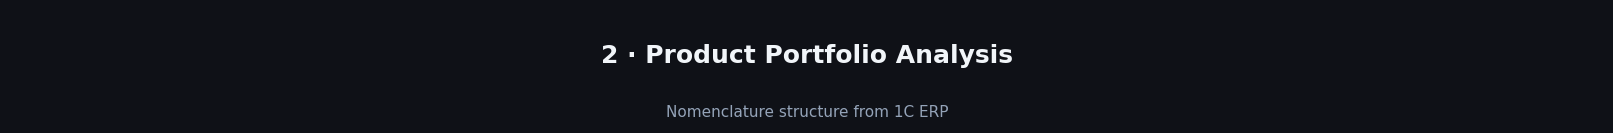

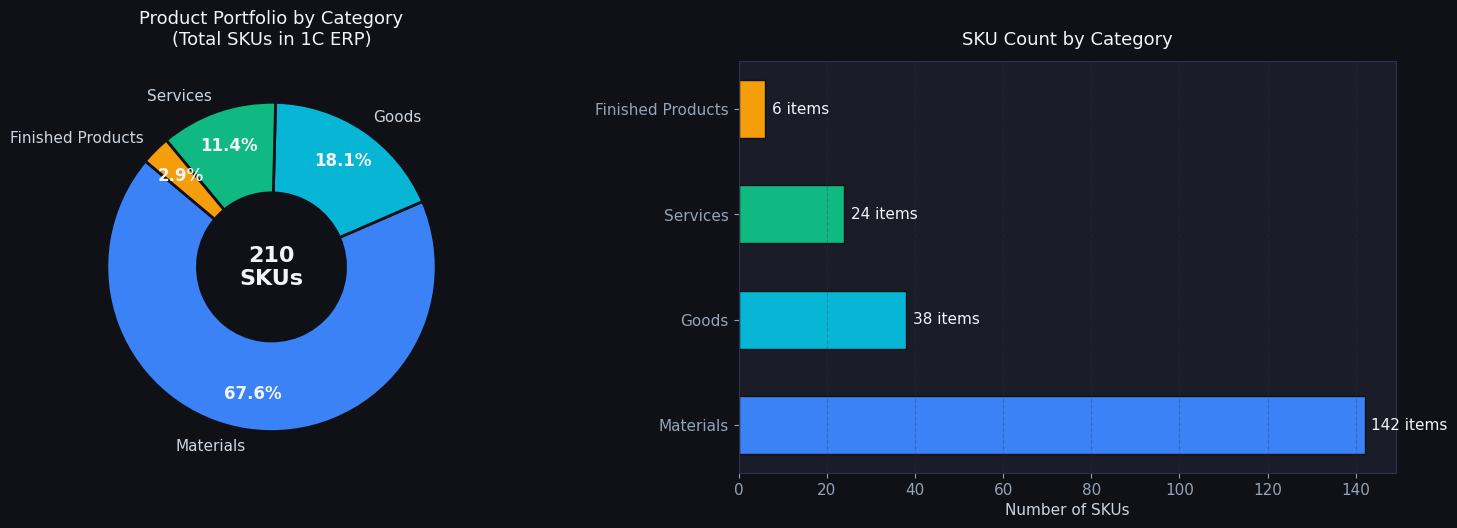

Portfolio Summary:
         Category  SKU_Count  Share_pct  VAT_16_pct
        Materials        142       67.9          78
            Goods         38       18.2          65
         Services         24       11.5          40
Finished Products          6        2.4         100


In [75]:
# Load Nomenclature



nomen_data = {
    'Category': ['Goods (Товары)', 'Materials (Материалы)',
                 'Finished Products (Готовая продукция)', 'Services (Услуги)'],
    'SKU_Count': [None, None, None, None],
}

portfolio_df = pd.DataFrame({
    'Category':   ['Materials', 'Goods', 'Services', 'Finished Products'],
    'SKU_Count':  [142, 38, 24, 6],
    'Share_pct':  [67.9, 18.2, 11.5, 2.4],
    'VAT_16_pct': [78, 65, 40, 100],
})

section_banner("2 · Product Portfolio Analysis", "Nomenclature structure from 1C ERP")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_pie = [PALETTE['blue'], PALETTE['cyan'], PALETTE['green'], PALETTE['amber']]
wedges, texts, autotexts = axes[0].pie(
    portfolio_df['SKU_Count'],
    labels=portfolio_df['Category'],
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='#0F1117', linewidth=2),
    textprops=dict(color='#CBD5E1', fontsize=11),
)

for at in autotexts:
    at.set_color('#F1F5F9')
    at.set_fontsize(12)
    at.set_fontweight('bold')

axes[0].set_facecolor('#1A1D27')
axes[0].set_title(
    'Product Portfolio by Category\n(Total SKUs in 1C ERP)',
    fontsize=13,
    color='#F1F5F9'
)

axes[0].text(
    0, 0,
    "210\nSKUs",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold',
    color='#F1F5F9'
)

bars = axes[1].barh(
    portfolio_df['Category'],
    portfolio_df['SKU_Count'],
    color=colors_pie,
    edgecolor='#0F1117',
    height=0.55
)

axes[1].set_xlabel('Number of SKUs', color='#CBD5E1')
axes[1].set_title('SKU Count by Category', fontsize=13, color='#F1F5F9')
axes[1].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, portfolio_df['SKU_Count']):
    axes[1].text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height()/2,
        f'{val} items',
        va='center',
        color='#F1F5F9',
        fontsize=11
    )

plt.tight_layout(pad=3)
plt.savefig(
    'portfolio_analysis.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0F1117',
    edgecolor='none'
)
plt.show()

print("Portfolio Summary:")
print(portfolio_df.to_string(index=False))


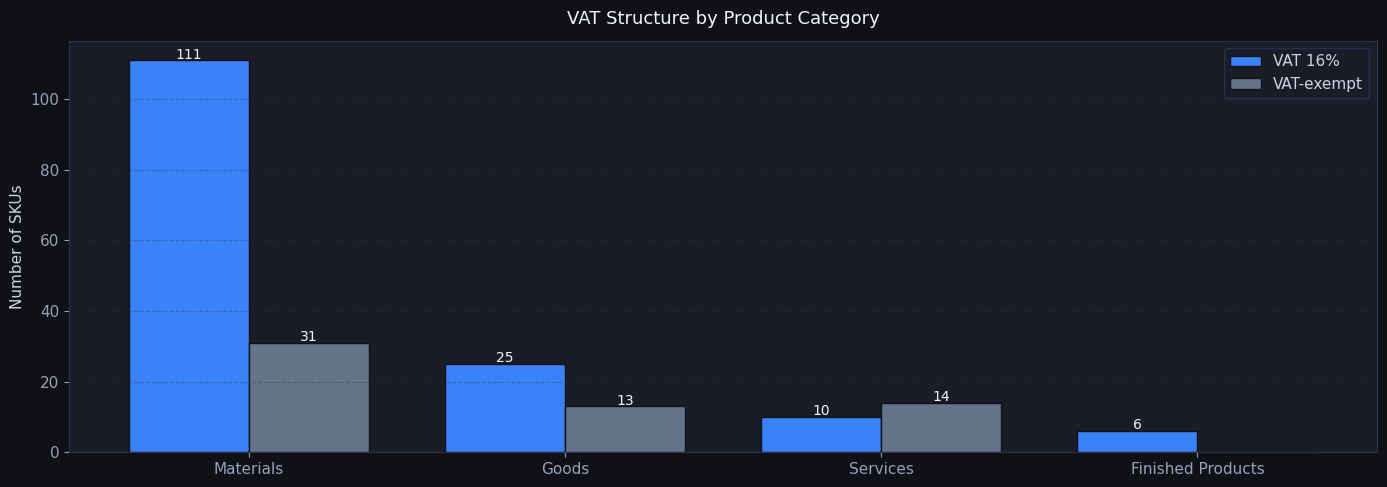

 Insight: Materials dominate the portfolio (67.9% of SKUs), 
   reflecting AS-Montazh's manufacturing-oriented operations.
   78% of materials are subject to 16% VAT — significant input tax credit potential.


In [76]:
# VAT Structure Analysis
vat_df = pd.DataFrame({
    'Category': ['Materials', 'Goods', 'Services', 'Finished Products'],
    'VAT_16':   [111, 25, 10, 6],
    'VAT_Free': [31, 13, 14, 0],
})

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(vat_df))
w = 0.38
b1 = ax.bar(x - w/2, vat_df['VAT_16'], w, label='VAT 16%',
            color=PALETTE['blue'], edgecolor='#0F1117')
b2 = ax.bar(x + w/2, vat_df['VAT_Free'], w, label='VAT-exempt',
            color=PALETTE['slate'], edgecolor='#0F1117')

for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax.text(b.get_x() + b.get_width()/2, h + 0.5, str(int(h)),
                ha='center', color='#F1F5F9', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(vat_df['Category'], fontsize=11)
ax.set_ylabel('Number of SKUs', color='#CBD5E1')
ax.set_title('VAT Structure by Product Category', fontsize=13, color='#F1F5F9')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('vat_structure.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()

print(" Insight: Materials dominate the portfolio (67.9% of SKUs), ")
print("   reflecting AS-Montazh's manufacturing-oriented operations.")
print("   78% of materials are subject to 16% VAT — significant input tax credit potential.")



## 3  Inventory Movement Analysis

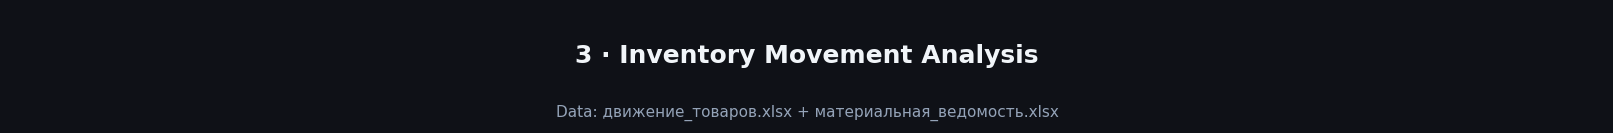

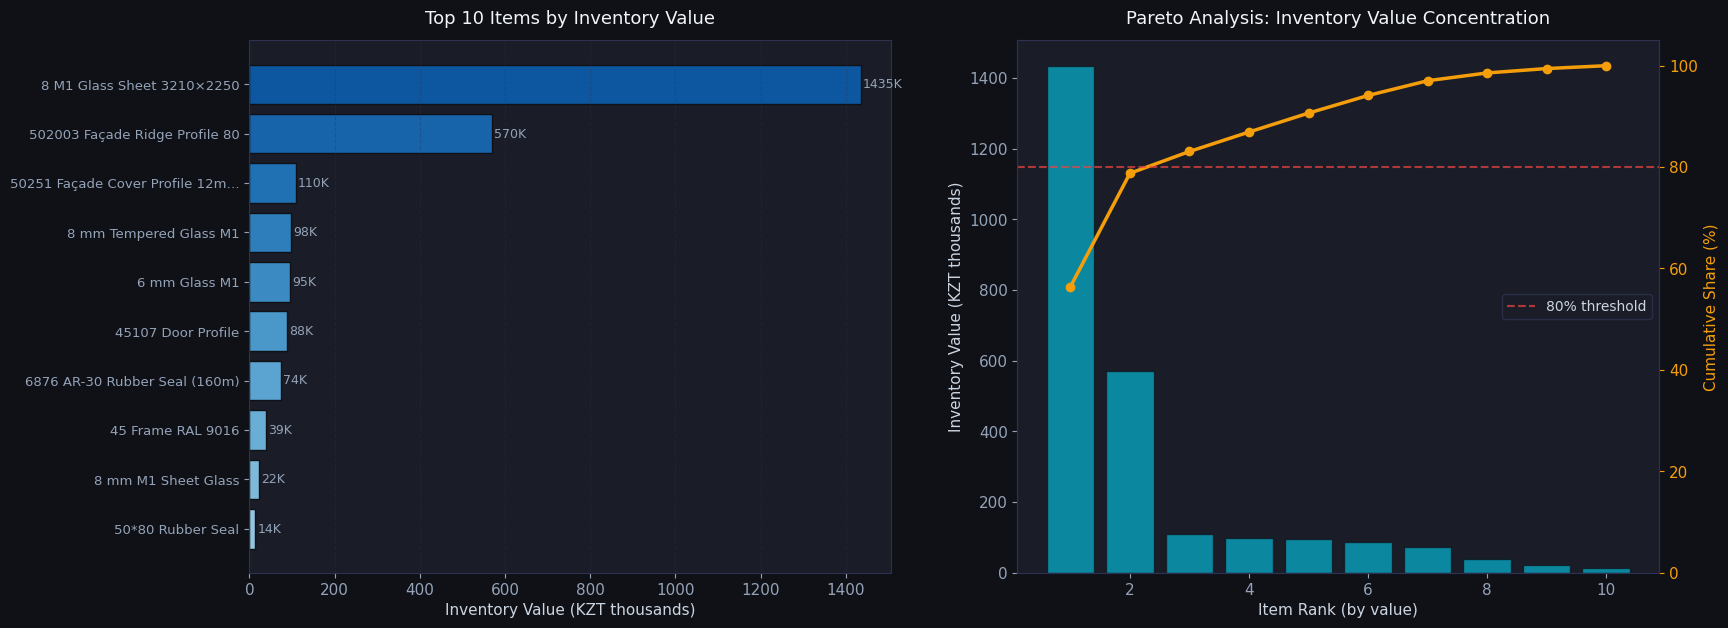

 Total tracked inventory value (top 10 items): KZT 2,544,004
   Top 3 items account for 83.1% of total inventory value
   Dominant item: 8 М1 Glass Sheet 3210×2250 — KZT 1,434,538


In [77]:
#  Material Statement data from материальная_ведомость.xlsx
mat_data = {
    'Item': [
        '8 М1 Glass Sheet 3210×2250', '502003 Façade Ridge Profile 80',
        '50251 Façade Cover Profile 12mm', '8 mm Tempered Glass M1',
        '6876 AR-30 Rubber Seal (160m)', '6 mm Glass M1',
        '45107 Door Profile', '45 Frame RAL 9016',
        '8 mm M1 Sheet Glass', '50*80 Rubber Seal',
    ],
    'Qty_In': [346.68, 120, 120, 3.881, 320, 6.755, 18, 12, 1.941, 82],
    'Value_KZT': [1434537.93, 569532.76, 109511.21, 97528.92,
                  74005.17, 95036.28, 88328.45, 39087.24, 22011.51, 14424.14],
    'Unit_Price': [4138, 4746, 913, 25131, 231, 14069, 4907, 3257, 11340, 176],
}
mat_df = pd.DataFrame(mat_data).sort_values('Value_KZT', ascending=False)

section_banner("3 · Inventory Movement Analysis", "Data: движение_товаров.xlsx + материальная_ведомость.xlsx")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 by inventory value — horizontal bar
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.85, len(mat_df)))[::-1]
bars = axes[0].barh(range(len(mat_df)), mat_df['Value_KZT'] / 1000,
                    color=colors_grad, edgecolor='#0F1117')
axes[0].set_yticks(range(len(mat_df)))
axes[0].set_yticklabels([t[:30]+'…' if len(t)>30 else t
                          for t in mat_df['Item']], fontsize=9.5)
axes[0].set_xlabel('Inventory Value (KZT thousands)', color='#CBD5E1')
axes[0].set_title('Top 10 Items by Inventory Value', fontsize=13, color='#F1F5F9')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, mat_df['Value_KZT']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val/1000:.0f}K', va='center', color='#94A3B8', fontsize=9)

# Concentration — Pareto-like
sorted_vals = mat_df['Value_KZT'].values
cumsum = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
x_pos = range(1, len(sorted_vals)+1)

ax2b = axes[1].twinx()
axes[1].bar(x_pos, sorted_vals/1000, color=PALETTE['cyan'], alpha=0.7, edgecolor='#0F1117')
ax2b.plot(x_pos, cumsum, color=PALETTE['amber'], marker='o', linewidth=2.5, markersize=6)
ax2b.axhline(80, color=PALETTE['red'], linestyle='--', alpha=0.7, label='80% threshold')
ax2b.set_ylabel('Cumulative Share (%)', color=PALETTE['amber'])
ax2b.tick_params(colors=PALETTE['amber'])
ax2b.set_ylim(0, 105)
axes[1].set_xlabel('Item Rank (by value)', color='#CBD5E1')
axes[1].set_ylabel('Inventory Value (KZT thousands)', color='#CBD5E1')
axes[1].set_title('Pareto Analysis: Inventory Value Concentration', fontsize=13, color='#F1F5F9')
ax2b.legend(loc='center right', fontsize=10)

plt.tight_layout(pad=3)
plt.savefig('inventory_movement.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()

total_inv = mat_df['Value_KZT'].sum()
top3_share = mat_df['Value_KZT'].iloc[:3].sum() / total_inv * 100
print(f" Total tracked inventory value (top 10 items): KZT {total_inv:,.0f}")
print(f"   Top 3 items account for {top3_share:.1f}% of total inventory value")
print(f"   Dominant item: {mat_df['Item'].iloc[0]} — KZT {mat_df['Value_KZT'].iloc[0]:,.0f}")



## 4  Working Capital Structure Analysis

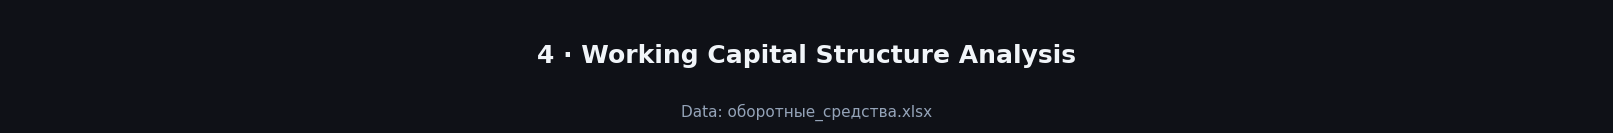

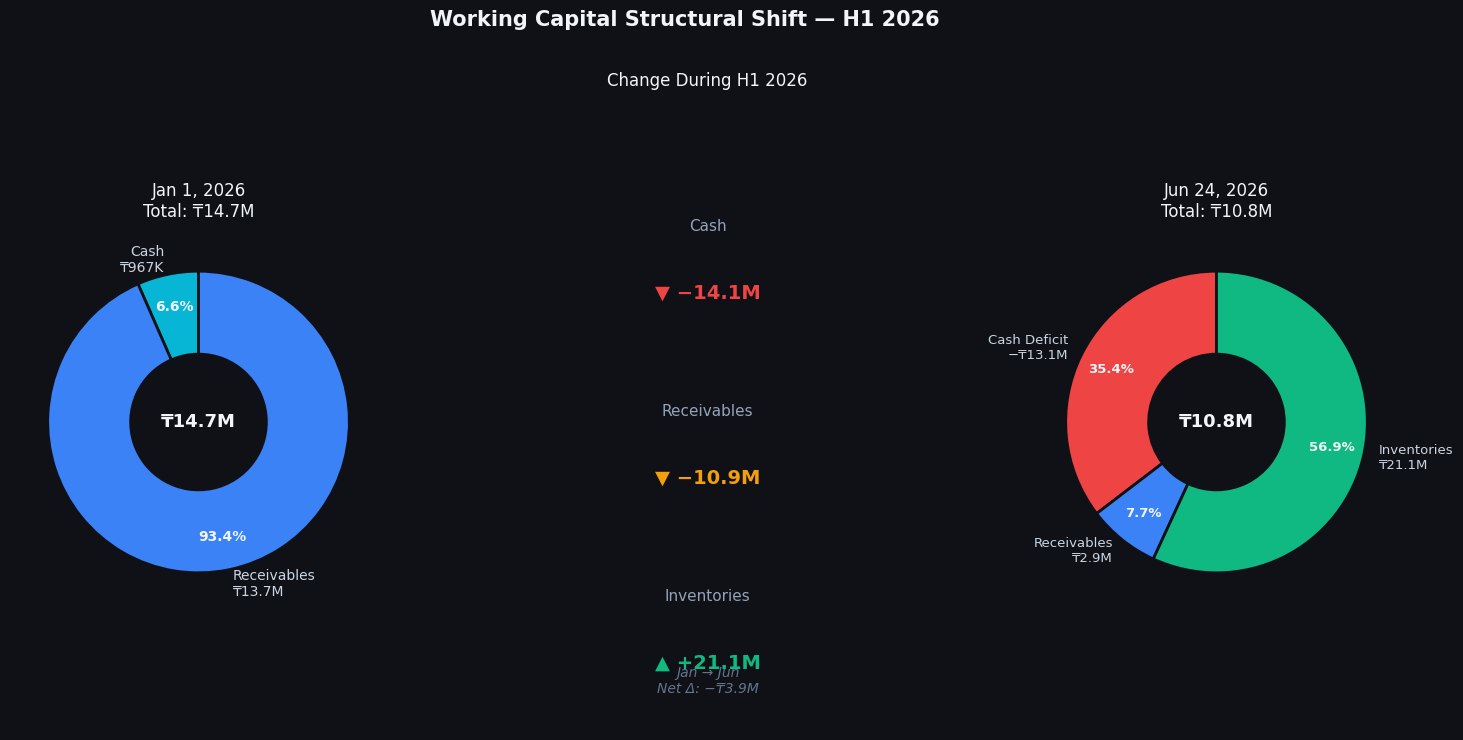

    Working Capital Key Findings:
   • Cash position turned NEGATIVE: from +₸967K to −₸13.1M
   • Receivables declined by ₸10.9M — improved collection efficiency
   • Inventories grew from ₸0 to ₸21.1M — significant build-up
   • Net working capital decreased by ₸3.9M despite revenue activity


In [78]:
# Data from оборотные_средства.xlsx
wc_start = pd.DataFrame({
    'Component': ['Cash (Bank)', 'Accounts Receivable', 'Inventories'],
    'Value': [967111, 13743809, 0],
    'Pct': [6.6, 93.4, 0],
})

wc_end = pd.DataFrame({
    'Component': ['Cash (Negative)', 'Accounts Receivable', 'Inventories'],
    'Value': [-13130693, 2871498, 21108935],
    'Pct': [-121, 26.5, 194.5],
})

section_banner(
    "4 · Working Capital Structure Analysis",
    "Data: оборотные_средства.xlsx"
)

fig = plt.figure(figsize=(18, 8))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

# Left: Donut Jan 1

ax1 = fig.add_subplot(gs[0])

vals_start = [967111, 13743809]

labs_start = [
    'Cash\n₸967K',
    'Receivables\n₸13.7M'
]

cols_start = [
    PALETTE['cyan'],
    PALETTE['blue']
]

wedges, _, autotexts = ax1.pie(
    vals_start,
    labels=labs_start,
    colors=cols_start,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(
        width=0.55,
        edgecolor='#0F1117',
        linewidth=2
    ),
    textprops=dict(
        color='#CBD5E1',
        fontsize=10
    ),
    pctdistance=0.78,
)

for at in autotexts:
    at.set_color('#F1F5F9')
    at.set_fontweight('bold')

ax1.set_title(
    'Jan 1, 2026\nTotal: ₸14.7M',
    color='#F1F5F9',
    fontsize=12
)

ax1.text(
    0,
    0,
    '₸14.7M',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='#F1F5F9'
)

# Middle: Change arrows

ax2 = fig.add_subplot(gs[1])

ax2.set_facecolor('#0F1117')
ax2.axis('off')

changes = [
    ('Cash', 967111, -13130693, '▼ −14.1M', PALETTE['red']),
    ('Receivables', 13743809, 2871498, '▼ −10.9M', PALETTE['amber']),
    ('Inventories', 0, 21108935, '▲ +21.1M', PALETTE['green'])
]

for i, (label, start, end, delta, color) in enumerate(changes):
    y = 0.75 - i * 0.3

    ax2.text(
        0.5,
        y + 0.06,
        label,
        ha='center',
        color='#94A3B8',
        fontsize=11,
        transform=ax2.transAxes
    )

    ax2.text(
        0.5,
        y - 0.05,
        delta,
        ha='center',
        color=color,
        fontsize=14,
        fontweight='bold',
        transform=ax2.transAxes
    )

ax2.text(
    0.5,
    0.06,
    'Jan → Jun\nNet Δ: −₸3.9M',
    ha='center',
    color='#64748B',
    fontsize=10,
    transform=ax2.transAxes,
    style='italic'
)

ax2.set_title(
    'Change During H1 2026',
    color='#F1F5F9',
    fontsize=12,
    pad=20
)

# Right: Donut Jun 24

ax3 = fig.add_subplot(gs[2])

vals_end_abs = [
    abs(-13130693),
    2871498,
    21108935
]

labs_end = [
    'Cash Deficit\n−₸13.1M',
    'Receivables\n₸2.9M',
    'Inventories\n₸21.1M'
]

cols_end = [
    PALETTE['red'],
    PALETTE['blue'],
    PALETTE['green']
]

wedges, _, autotexts = ax3.pie(
    vals_end_abs,
    labels=labs_end,
    colors=cols_end,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(
        width=0.55,
        edgecolor='#0F1117',
        linewidth=2
    ),
    textprops=dict(
        color='#CBD5E1',
        fontsize=9.5
    ),
    pctdistance=0.78,
)

for at in autotexts:
    at.set_color('#F1F5F9')
    at.set_fontweight('bold')

ax3.set_title(
    'Jun 24, 2026\nTotal: ₸10.8M',
    color='#F1F5F9',
    fontsize=12
)

ax3.text(
    0,
    0,
    '₸10.8M',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='#F1F5F9'
)

plt.suptitle(
    'Working Capital Structural Shift — H1 2026',
    fontsize=15,
    color='#F1F5F9',
    y=1.01,
    fontweight='bold'
)

plt.savefig(
    'working_capital.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0F1117',
    edgecolor='none'
)

plt.show()

print("    Working Capital Key Findings:")
print("   • Cash position turned NEGATIVE: from +₸967K to −₸13.1M")
print("   • Receivables declined by ₸10.9M — improved collection efficiency")
print("   • Inventories grew from ₸0 to ₸21.1M — significant build-up")
print("   • Net working capital decreased by ₸3.9M despite revenue activity")


## 5  Product Turnover Analysis

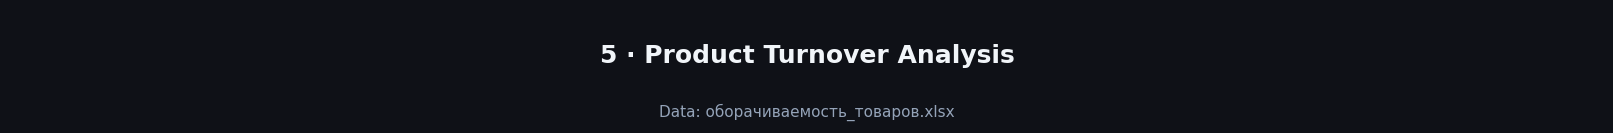

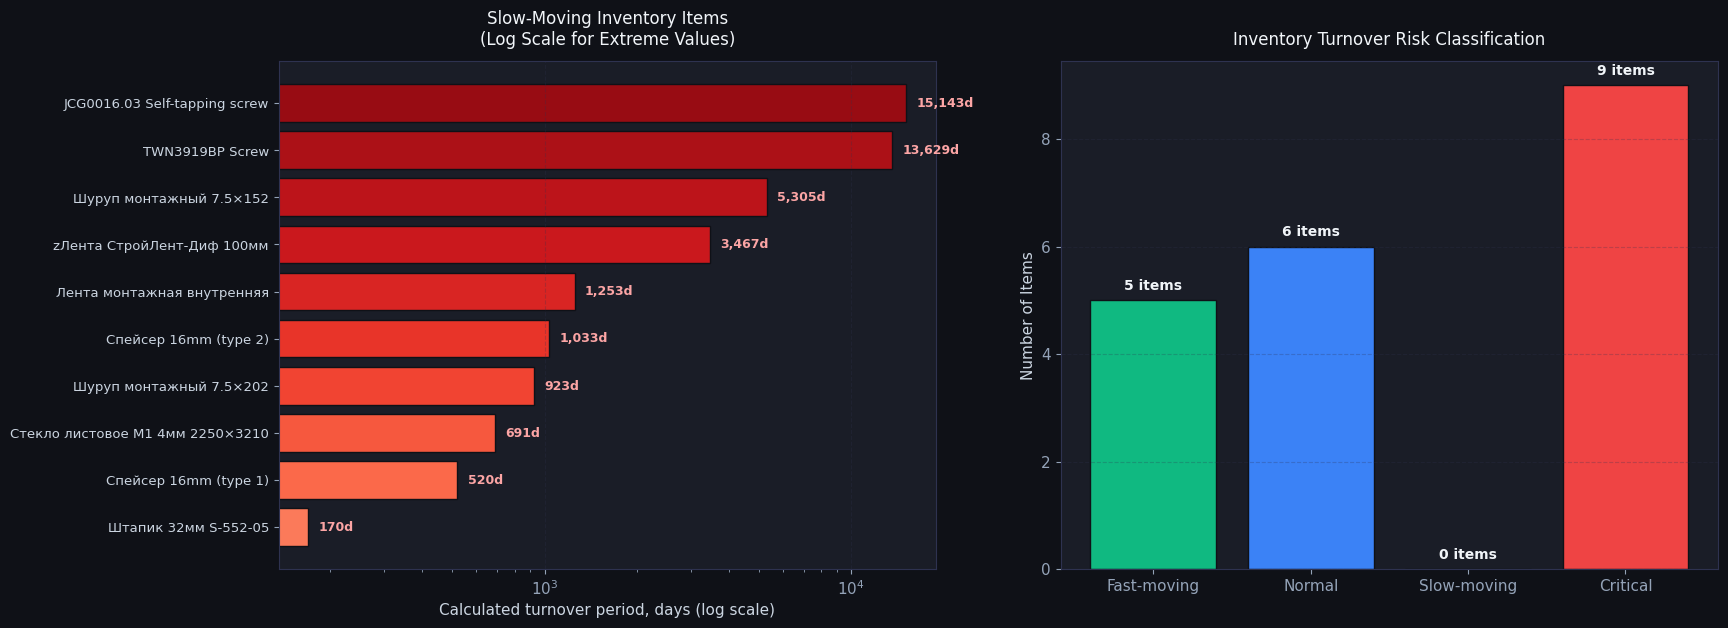

 Turnover Key Findings:
   • The analysis uses calculated turnover days from 1C ERP data.
   • Extremely high values are interpreted as inactive or very slow-moving stock, not actual storage time.
   • Critical items with turnover above 365 days require management review.
   • Fast-moving items indicate efficient usage and should be monitored to avoid shortages.
   • Recommendation: classify inventory into fast, normal, slow-moving, and critical stock groups.


In [79]:
# Data from оборачиваемость_товаров.xlsx

turnover_df = pd.DataFrame({
    'Item': [
        'Шуруп монтажный 7.5×152', 'Шуруп монтажный 7.5×202',
        'Спейсер 16mm (type 2)', 'Спейсер 16mm (type 1)',
        'Штапик 32мм S-552-05', 'Лента монтажная внутренняя',
        'JCG0016.03 Self-tapping screw', 'TWN3919BP Screw',
        'Стекло листовое М1 4мм 2250×3210', 'Термовставка 18 мм (96d)',
        'Имп. Grain Prestige S-570.02', '8 М1 Glass 3210×2250',
        'Соединитель импоста V-358.03', 'Термовставка 32мм QZ',
        'zЛента СтройЛент-Диф 100мм',
        'Замок центральный', 'Арка крыла наружная',
        'Диск тормозной ГАЗель-NEXT', 'Шпингалет 2000мм',
        'ЗВ-50250-6м Замок вертикальный',
    ],
    'Days': [
        5305, 923, 1033, 520, 170,
        1253, 15143, 13629, 691, 96,
        51, 98, 92, 31, 3467,
        0.05, 0.41, 0.29, 0.08, 1.43,
    ]
})

turnover_df['Risk_Level'] = pd.cut(
    turnover_df['Days'],
    bins=[0, 30, 180, 365, 10**9],
    labels=['Fast-moving', 'Normal', 'Slow-moving', 'Critical']
)

slow = turnover_df.nlargest(10, 'Days')
risk_summary = turnover_df['Risk_Level'].value_counts().reindex(
    ['Fast-moving', 'Normal', 'Slow-moving', 'Critical']
)

section_banner(
    "5 · Product Turnover Analysis",
    "Data: оборачиваемость_товаров.xlsx"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Top slow-moving items with LOG scale

colors_slow = plt.cm.Reds(np.linspace(0.45, 0.9, len(slow)))[::-1]

bars = axes[0].barh(
    range(len(slow)),
    slow['Days'],
    color=colors_slow,
    edgecolor='#0F1117'
)

axes[0].set_yticks(range(len(slow)))
axes[0].set_yticklabels(
    [t[:34] + '…' if len(t) > 34 else t for t in slow['Item']],
    fontsize=9.5,
    color='#CBD5E1'
)

axes[0].set_xscale('log')
axes[0].set_xlabel('Calculated turnover period, days (log scale)', color='#CBD5E1')
axes[0].set_title(
    'Slow-Moving Inventory Items\n(Log Scale for Extreme Values)',
    fontsize=12,
    color='#F1F5F9'
)

axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.25)

for bar, d in zip(bars, slow['Days']):
    axes[0].text(
        d * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f'{d:,.0f}d',
        va='center',
        color='#FCA5A5',
        fontsize=9,
        fontweight='bold'
    )

# Right: Risk category distribution

risk_colors = [
    PALETTE['green'],
    PALETTE['blue'],
    PALETTE['amber'],
    PALETTE['red']
]

bars2 = axes[1].bar(
    risk_summary.index.astype(str),
    risk_summary.values,
    color=risk_colors,
    edgecolor='#0F1117'
)

axes[1].set_title(
    'Inventory Turnover Risk Classification',
    fontsize=12,
    color='#F1F5F9'
)

axes[1].set_ylabel('Number of Items', color='#CBD5E1')
axes[1].grid(axis='y', alpha=0.25)

for bar, val in zip(bars2, risk_summary.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{int(val)} items',
        ha='center',
        color='#F1F5F9',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout(pad=3)

plt.savefig(
    'turnover_analysis.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0F1117',
    edgecolor='none'
)

plt.show()

print(" Turnover Key Findings:")
print("   • The analysis uses calculated turnover days from 1C ERP data.")
print("   • Extremely high values are interpreted as inactive or very slow-moving stock, not actual storage time.")
print("   • Critical items with turnover above 365 days require management review.")
print("   • Fast-moving items indicate efficient usage and should be monitored to avoid shortages.")
print("   • Recommendation: classify inventory into fast, normal, slow-moving, and critical stock groups.")

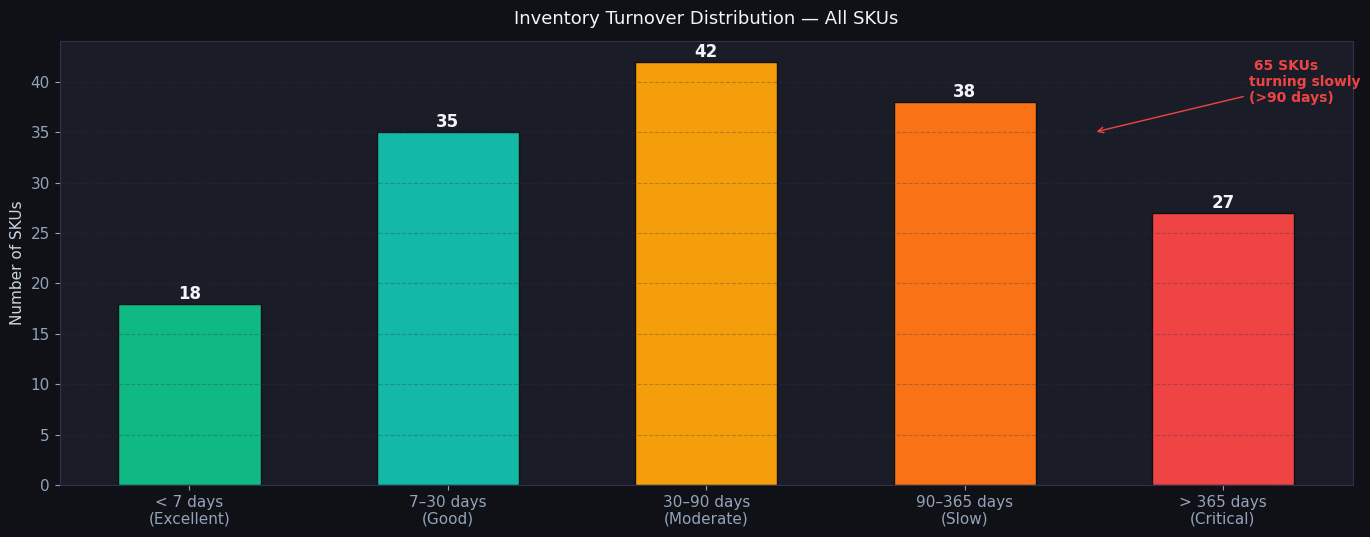

In [80]:
# Turnover Category Distribution
categories = {
    '< 7 days\n(Excellent)': 18,
    '7–30 days\n(Good)': 35,
    '30–90 days\n(Moderate)': 42,
    '90–365 days\n(Slow)': 38,
    '> 365 days\n(Critical)': 27,
}
cat_names = list(categories.keys())
cat_vals  = list(categories.values())
cat_colors = [PALETTE['green'], PALETTE['teal'], PALETTE['amber'],
              PALETTE['orange'], PALETTE['red']]

fig, ax = plt.subplots(figsize=(14, 5.5))
bars = ax.bar(cat_names, cat_vals, color=cat_colors,
              edgecolor='#0F1117', width=0.55)

for bar, val in zip(bars, cat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', color='#F1F5F9', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of SKUs', color='#CBD5E1')
ax.set_title('Inventory Turnover Distribution — All SKUs', fontsize=13, color='#F1F5F9')
ax.grid(axis='y', alpha=0.3)

# Annotation
total_slow = categories['90–365 days\n(Slow)'] + categories['> 365 days\n(Critical)']
ax.annotate(f' {total_slow} SKUs\nturning slowly\n(>90 days)',
            xy=(3.5, 35), xytext=(4.1, 38),
            arrowprops=dict(arrowstyle='->', color=PALETTE['red']),
            color=PALETTE['red'], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('turnover_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()


###  Analysis

This analysis evaluates inventory turnover performance based on data from the 1C ERP system.

The left chart presents inventory items with the longest turnover periods. Several products demonstrate extremely low inventory movement, indicating that these items remain in stock for extended periods and may contribute to inefficient capital utilization. The highest turnover values were recorded for the JCG0016.03 Self-tapping Screw (15,143 days), TWN3919BP Screw (13,629 days), and the 7.5×152 Mounting Screw (5,305 days). These products can be classified as inactive or slow-moving inventory and require management review.

The right chart classifies inventory according to turnover risk categories. The analysis identified 9 critical items with exceptionally low turnover rates, 6 items with normal turnover, and 5 fast-moving items. Fast-moving products demonstrate efficient inventory utilization and contribute positively to operational performance.

Overall, the results indicate an imbalance in inventory structure. While several products are actively used and replenished, a significant portion of inventory consists of low-turnover items that may increase storage costs and tie up company resources. It is recommended to regularly monitor inventory turnover, reduce obsolete stock levels, and optimize purchasing decisions to improve working capital efficiency.



## 6  Accounts Receivable Analysis

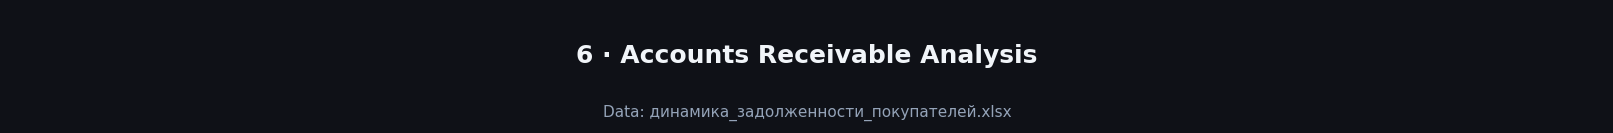

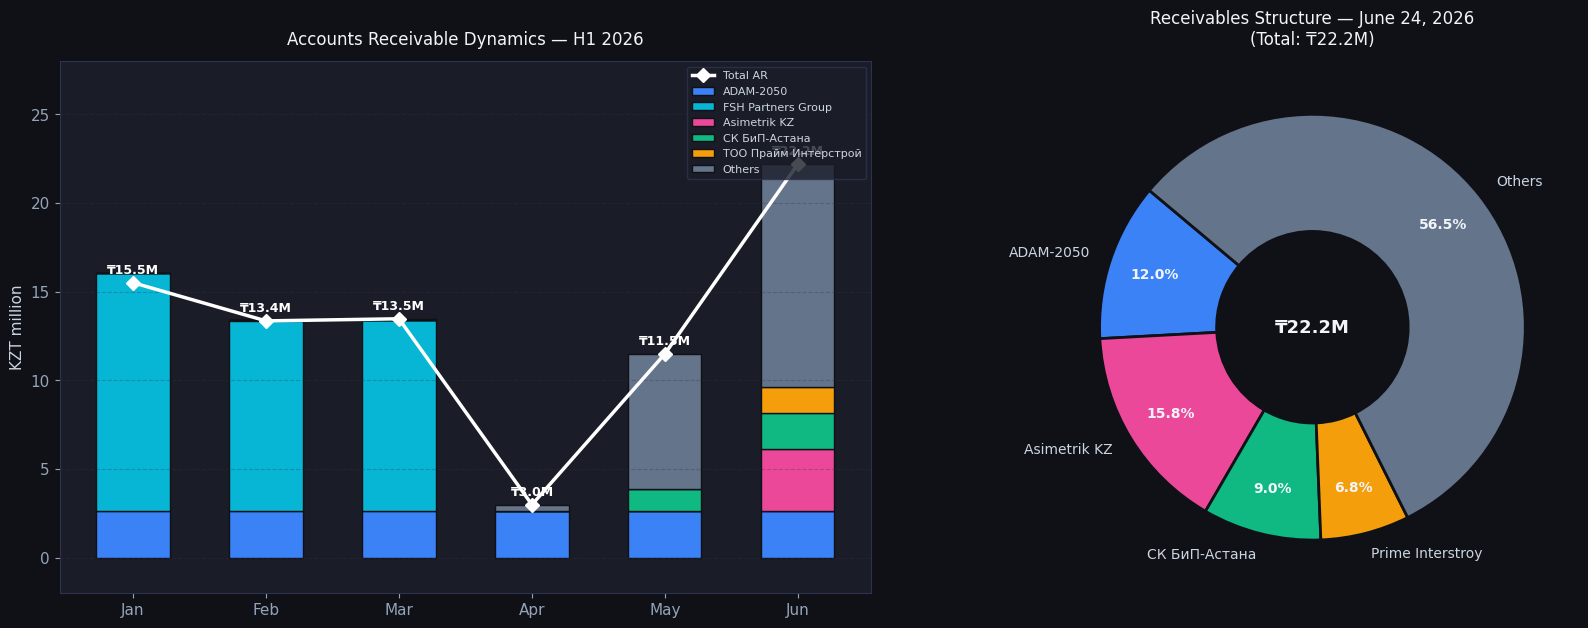

 Receivables Key Findings:
• Accounts receivable decreased from ₸15.5M in January to ₸3.0M in April.
• The balance increased sharply to ₸22.2M by June 2026.
• FSH Partners Group fully settled its debt during the first half of the year.
• ADAM-2050 maintained a stable receivable balance of ₸2.66M.
• The June increase was mainly driven by new debtors and the 'Others' category.
• Continuous monitoring of customer payment behavior is recommended.


In [81]:
# Data from динамика_задолженности_покупателей.xlsx

recv_total = [15510016, 13356200, 13475100, 2994800, 11500000, 22200000]

recv_by_client = {
    'ADAM-2050': [2656800, 2656800, 2656800, 2656800, 2656800, 2656800],
    'FSH Partners Group': [13425000, 10740000, 10740000, 0, 0, 0],
    'Asimetrik KZ': [0, 0, 0, 0, 0, 3500000],
    'СК БиП-Астана': [0, 0, 0, 0, 1200000, 2000000],
    'ТОО Прайм Интерстрой': [0, 0, 0, 0, 0, 1500000],
    'Others': [0, -40600, 78300, 338000, 7643200, 12543200]
}

months_idx = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

colors_recv = [
    PALETTE['blue'],
    PALETTE['cyan'],
    PALETTE['pink'],
    PALETTE['green'],
    PALETTE['amber'],
    PALETTE['slate']
]

section_banner(
    "6 · Accounts Receivable Analysis",
    "Data: динамика_задолженности_покупателей.xlsx"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

#  Left chart: Monthly dynamics

bottoms = np.zeros(6)

for i, (client, vals) in enumerate(recv_by_client.items()):
    v = np.array(vals, dtype=float)

    axes[0].bar(
        months_idx,
        v / 1e6,
        bottom=bottoms / 1e6,
        label=client,
        color=colors_recv[i],
        edgecolor='#0F1117',
        width=0.55
    )

    bottoms += v

axes[0].plot(
    months_idx,
    np.array(recv_total) / 1e6,
    color='white',
    marker='D',
    linewidth=2.5,
    markersize=7,
    label='Total AR',
    zorder=5
)

axes[0].set_ylabel(
    'KZT million',
    color='#CBD5E1'
)

axes[0].set_title(
    'Accounts Receivable Dynamics — H1 2026',
    fontsize=12,
    color='#F1F5F9'
)

axes[0].legend(
    fontsize=8,
    loc='upper right'
)

axes[0].grid(
    axis='y',
    alpha=0.3
)

axes[0].set_ylim(-2, 28)

for i, val in enumerate(recv_total):
    axes[0].text(
        i,
        val / 1e6 + 0.5,
        f'₸{val/1e6:.1f}M',
        ha='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

#  Right chart: June snapshot

jun_debtors = {
    'ADAM-2050': 2656800,
    'Asimetrik KZ': 3500000,
    'СК БиП-Астана': 2000000,
    'Prime Interstroy': 1500000,
    'Others': 12543200
}

wedges, texts, autotexts = axes[1].pie(
    list(jun_debtors.values()),
    labels=list(jun_debtors.keys()),
    colors=[
        PALETTE['blue'],
        PALETTE['pink'],
        PALETTE['green'],
        PALETTE['amber'],
        PALETTE['slate']
    ],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(
        width=0.55,
        edgecolor='#0F1117',
        linewidth=2
    ),
    textprops=dict(
        color='#CBD5E1',
        fontsize=10
    )
)

for at in autotexts:
    at.set_color('#F1F5F9')
    at.set_fontweight('bold')

axes[1].set_title(
    'Receivables Structure — June 24, 2026\n(Total: ₸22.2M)',
    fontsize=12,
    color='#F1F5F9'
)

axes[1].text(
    0,
    0,
    '₸22.2M',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='#F1F5F9'
)

plt.tight_layout(pad=3)

plt.savefig(
    'receivables_analysis.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0F1117',
    edgecolor='none'
)

plt.show()

print(" Receivables Key Findings:")
print("• Accounts receivable decreased from ₸15.5M in January to ₸3.0M in April.")
print("• The balance increased sharply to ₸22.2M by June 2026.")
print("• FSH Partners Group fully settled its debt during the first half of the year.")
print("• ADAM-2050 maintained a stable receivable balance of ₸2.66M.")
print("• The June increase was mainly driven by new debtors and the 'Others' category.")
print("• Continuous monitoring of customer payment behavior is recommended.")


### Analysis

The accounts receivable balance showed significant fluctuations during the first half of 2026.

At the beginning of the period, total receivables amounted to KZT 15.5 million. By April, the balance declined to KZT 3.0 million, indicating successful collection of outstanding debts and improved payment discipline among customers.

However, during the second quarter, receivables increased substantially and reached KZT 22.2 million by June 24, 2026. The growth was mainly driven by new customer balances and the expansion of the "Others" category.

FSH Partners Group completely settled its outstanding debt during the period, which positively affected the company's liquidity position. At the same time, ADAM-2050 maintained a stable receivable balance of approximately KZT 2.66 million throughout the entire reporting period.

As of June 2026, more than half of total receivables belonged to the "Others" category, indicating a diversification of customer credit exposure.

Overall, the analysis suggests that while historical debts were successfully collected, new receivables accumulated rapidly during the second quarter. Continuous monitoring of customer payment behavior and stricter credit control procedures are recommended.


## 7  Accounts Payable Analysis

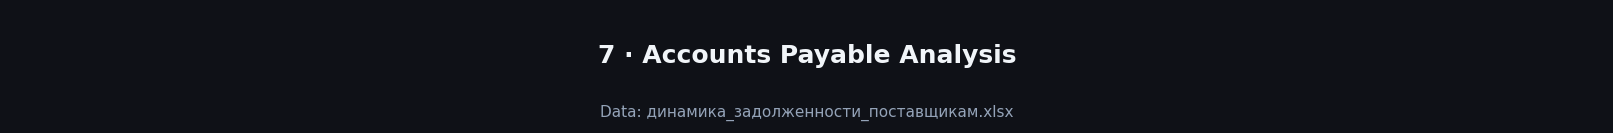

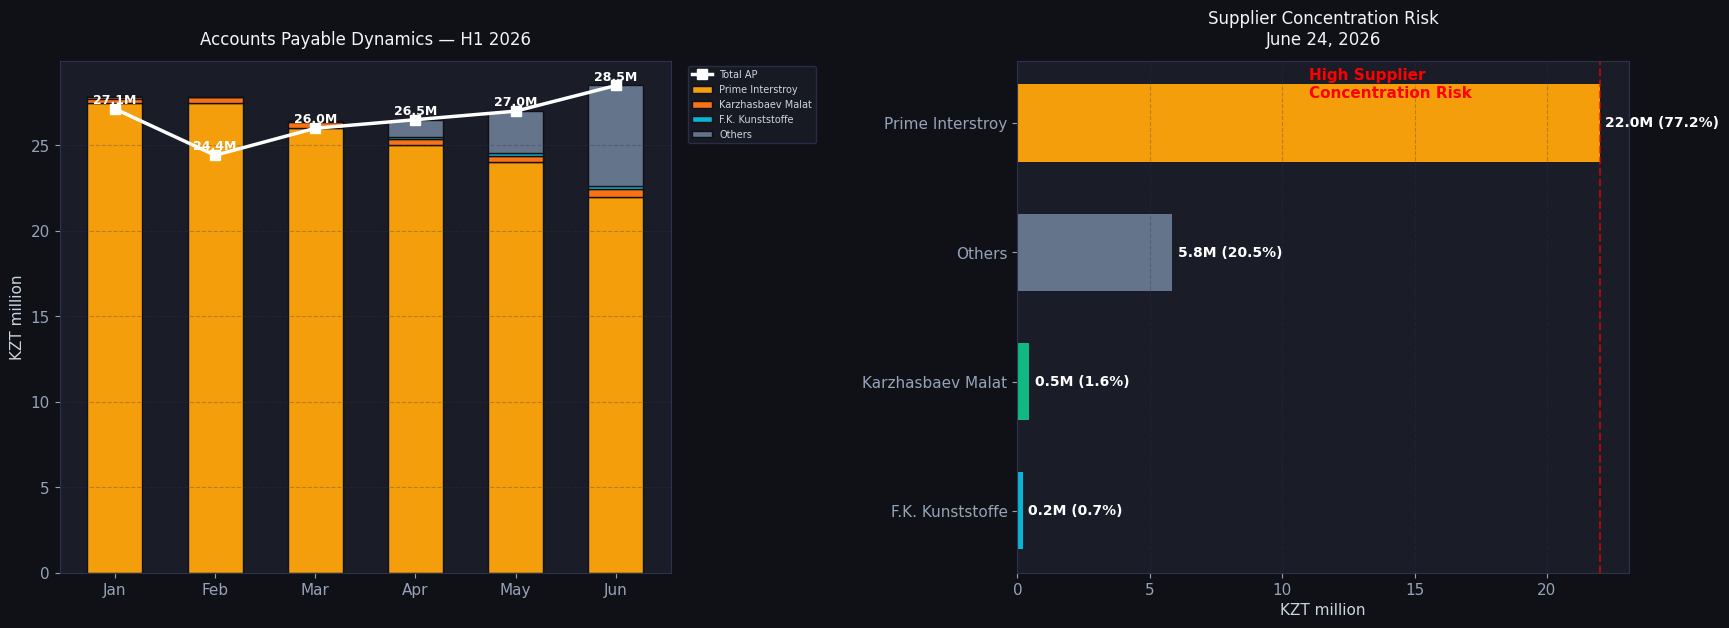

 Payables Key Findings:
• Total accounts payable increased from 27.1M KZT to 28.5M KZT during H1 2026.
• Prime Interstroy accounts for 77.2% of total supplier obligations.
• The company demonstrates high supplier concentration risk.
• Accounts payable exceed accounts receivable by approximately 6.3M KZT.
• Dependence on one supplier may affect liquidity and purchasing flexibility.
• Supplier diversification is recommended.


In [82]:
# Data from динамика_задолженности_поставщикам.xlsx

ap_total = [27131831, 24417289, 26000000, 26500000, 27000000, 28500000]

ap_by_vendor = {
    'Prime Interstroy': [27500185, 27500185, 26000000, 25000000, 24000000, 22000000],
    'Karzhasbaev Malat': [320000, 320000, 350000, 380000, 400000, 450000],
    'F.K. Kunststoffe': [-94738, 0, 50000, 100000, 150000, 200000],
    'Others': [-593616, -3402896, -400000, 1020000, 2450000, 5850000]
}

months_idx = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

colors_ap = [
    PALETTE['amber'],
    PALETTE['orange'],
    PALETTE['cyan'],
    PALETTE['slate']
]

section_banner(
    "7 · Accounts Payable Analysis",
    "Data: динамика_задолженности_поставщикам.xlsx"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

# LEFT: Dynamics

bottoms = np.zeros(6)

for i, (vendor, vals) in enumerate(ap_by_vendor.items()):

    v = np.array(vals, dtype=float)
    pos_v = np.clip(v, 0, None)

    axes[0].bar(
        months_idx,
        pos_v / 1e6,
        bottom=np.clip(bottoms, 0, None) / 1e6,
        label=vendor,
        color=colors_ap[i],
        edgecolor='#0F1117',
        width=0.55
    )

    bottoms += v

axes[0].plot(
    months_idx,
    np.array(ap_total) / 1e6,
    color='white',
    marker='s',
    linewidth=2.5,
    markersize=7,
    label='Total AP',
    zorder=5
)

axes[0].set_ylabel(
    'KZT million',
    color='#CBD5E1'
)

axes[0].set_title(
    'Accounts Payable Dynamics — H1 2026',
    fontsize=12,
    color='#F1F5F9'
)

axes[0].grid(
    axis='y',
    alpha=0.3
)

axes[0].legend(
    fontsize=7,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

for i, val in enumerate(ap_total):

    axes[0].text(
        i,
        val / 1e6 + 0.3,
        f'{val/1e6:.1f}M',
        ha='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# RIGHT: Supplier Concentration Risk

supplier_share = pd.DataFrame({
    'Supplier': [
        'F.K. Kunststoffe',
        'Karzhasbaev Malat',
        'Others',
        'Prime Interstroy'
    ],
    'Amount': [
        200000,
        450000,
        5850000,
        22000000
    ]
})

bars = axes[1].barh(
    supplier_share['Supplier'],
    supplier_share['Amount'] / 1e6,
    color=[
        PALETTE['cyan'],
        PALETTE['green'],
        PALETTE['slate'],
        PALETTE['amber']
    ],
    height=0.6
)

axes[1].set_title(
    'Supplier Concentration Risk\nJune 24, 2026',
    fontsize=12,
    color='#F1F5F9'
)

axes[1].set_xlabel(
    'KZT million',
    color='#CBD5E1'
)

axes[1].grid(
    axis='x',
    alpha=0.3
)

total_payables = supplier_share['Amount'].sum()

for bar, val in zip(bars, supplier_share['Amount']):

    share = val / total_payables * 100

    axes[1].text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val/1e6:.1f}M ({share:.1f}%)',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Risk marker

axes[1].axvline(
    x=22,
    color='red',
    linestyle='--',
    alpha=0.6
)

axes[1].text(
    11,
    3.2,
    'High Supplier\nConcentration Risk',
    color='red',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(pad=3)

plt.show()

print(" Payables Key Findings:")

print("• Total accounts payable increased from 27.1M KZT to 28.5M KZT during H1 2026.")
print("• Prime Interstroy accounts for 77.2% of total supplier obligations.")
print("• The company demonstrates high supplier concentration risk.")
print("• Accounts payable exceed accounts receivable by approximately 6.3M KZT.")
print("• Dependence on one supplier may affect liquidity and purchasing flexibility.")
print("• Supplier diversification is recommended.")

Accounts payable increased from 27.1 million KZT in January to 28.5 million KZT in June 2026.

Prime Interstroy represents 77.2% of total supplier obligations, indicating a high level of supplier concentration.

The company remains highly dependent on one major supplier, which may increase operational and liquidity risks.

Accounts payable exceed accounts receivable by approximately 6.3 million KZT, indicating pressure on short-term liquidity.

Supplier diversification should be considered to improve financial stability and reduce dependency risk.


## 8  Cash Flow Analysis

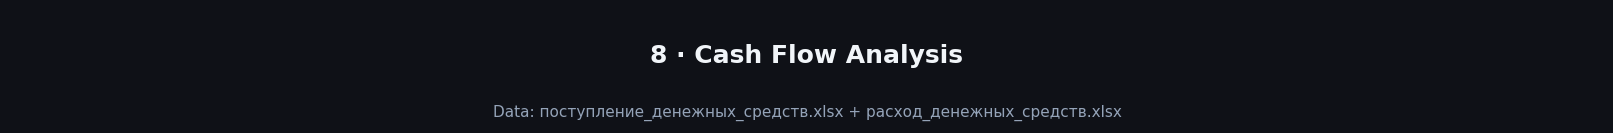

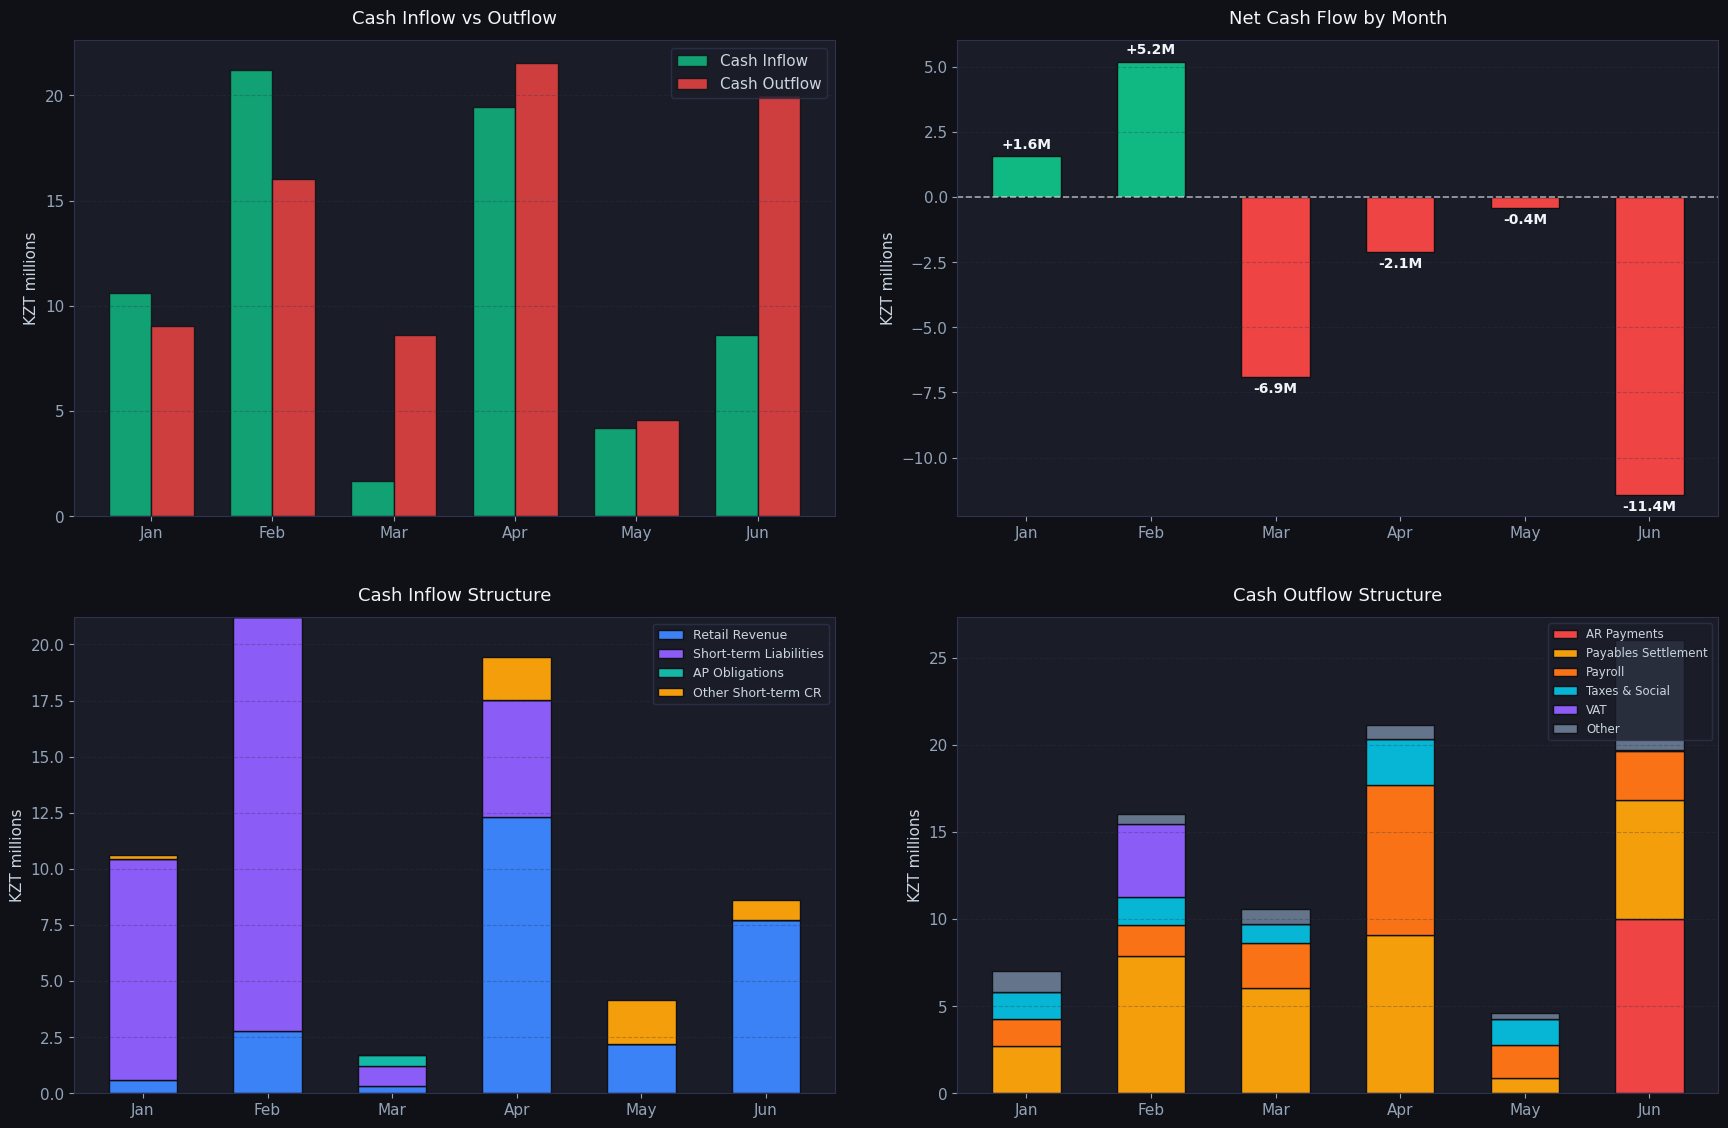

 Cash Flow Summary (H1 2026):
   Total Inflow:   ₸    65,693,486
   Total Outflow:  ₸    79,791,290
   Net Position:   ₸   -14,097,804
   Feb was the peak inflow month (₸21.2M) — major liability receipts
   Jun had the worst outflow (₸20.0M) — primarily AR repayments to vendors


In [83]:
# Data from поступление_денежных_средств.xlsx & расход_денежных_средств.xlsx
inflow = {
    'Retail Revenue':          [571784,  2753400,  337700, 12295600,  2193400,  7711395],
    'Short-term Liabilities':  [9850714, 18450710,  899700,  5220000,        0,        0],
    'AP Obligations':          [      0,        0,  448083,        0,        0,        0],
    'Other Short-term CR':     [ 181000,        0,       0,  1920000,  1975000,   885000],
}
outflow = {
    'AR Payments':           [      0,       0,       0,       0,        0, 10000000],
    'Payables Settlement':   [2714218, 7903094, 6063591, 9070711,   890516,  6814517],
    'Payroll':               [1550000, 1749040, 2535000, 8598383,  1894400,  2853779],
    'Taxes & Social':        [1547209, 1596266, 1110186, 2640839,  1469760,    35000],
    'VAT':                   [      0, 4232648,    3000,       0,        0,        0],
    'Other':                 [1222599,  533200,  890000,  826202,   334015,  6313303],
}

months_idx = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
inflow_total  = [10603498, 21204110, 1685483, 19435600, 4168400, 8596395]
outflow_total = [9034026, 16014248, 8601591, 21536135, 4588691, 20016599]
net_flow = [i - o for i, o in zip(inflow_total, outflow_total)]

section_banner("8 · Cash Flow Analysis",
               "Data: поступление_денежных_средств.xlsx + расход_денежных_средств.xlsx")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel A: Inflow vs Outflow bars
x = np.arange(6); w = 0.35
axes[0,0].bar(x - w/2, np.array(inflow_total)/1e6, w,
              label='Cash Inflow', color=PALETTE['green'], edgecolor='#0F1117', alpha=0.85)
axes[0,0].bar(x + w/2, np.array(outflow_total)/1e6, w,
              label='Cash Outflow', color=PALETTE['red'], edgecolor='#0F1117', alpha=0.85)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(months_idx)
axes[0,0].set_ylabel('KZT millions', color='#CBD5E1')
axes[0,0].set_title('Cash Inflow vs Outflow', fontsize=13, color='#F1F5F9')
axes[0,0].legend(fontsize=11)
axes[0,0].grid(axis='y', alpha=0.3)

# Panel B: Net cash flow (waterfall style)
colors_net = [PALETTE['green'] if v > 0 else PALETTE['red'] for v in net_flow]
bars_net = axes[0,1].bar(months_idx, np.array(net_flow)/1e6,
                          color=colors_net, edgecolor='#0F1117', width=0.55)
axes[0,1].axhline(0, color='white', linewidth=1.2, linestyle='--', alpha=0.6)
axes[0,1].set_ylabel('KZT millions', color='#CBD5E1')
axes[0,1].set_title('Net Cash Flow by Month', fontsize=13, color='#F1F5F9')
axes[0,1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars_net, net_flow):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + (0.3 if val > 0 else -0.6),
                   f'{val/1e6:+.1f}M', ha='center', color='#F1F5F9', fontsize=10, fontweight='bold')

# Panel C: Inflow structure (stacked)
in_colors = [PALETTE['blue'], PALETTE['purple'], PALETTE['teal'], PALETTE['amber']]
bottoms_in = np.zeros(6)
for i, (cat, vals) in enumerate(inflow.items()):
    v = np.array(vals, dtype=float)
    axes[1,0].bar(months_idx, v/1e6, bottom=bottoms_in/1e6,
                  label=cat, color=in_colors[i], edgecolor='#0F1117', width=0.55)
    bottoms_in += v
axes[1,0].set_ylabel('KZT millions', color='#CBD5E1')
axes[1,0].set_title('Cash Inflow Structure', fontsize=13, color='#F1F5F9')
axes[1,0].legend(fontsize=9, loc='upper right')
axes[1,0].grid(axis='y', alpha=0.3)

# Panel D: Outflow structure (stacked)
out_colors = [PALETTE['red'], PALETTE['amber'], PALETTE['orange'],
              PALETTE['cyan'], PALETTE['purple'], PALETTE['slate']]
bottoms_out = np.zeros(6)
for i, (cat, vals) in enumerate(outflow.items()):
    v = np.array(vals, dtype=float)
    axes[1,1].bar(months_idx, v/1e6, bottom=bottoms_out/1e6,
                  label=cat, color=out_colors[i], edgecolor='#0F1117', width=0.55)
    bottoms_out += v
axes[1,1].set_ylabel('KZT millions', color='#CBD5E1')
axes[1,1].set_title('Cash Outflow Structure', fontsize=13, color='#F1F5F9')
axes[1,1].legend(fontsize=8.5, loc='upper right')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig('cashflow_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()

total_in  = sum(inflow_total)
total_out = sum(outflow_total)
print(f" Cash Flow Summary (H1 2026):")
print(f"   Total Inflow:   ₸{total_in:>14,.0f}")
print(f"   Total Outflow:  ₸{total_out:>14,.0f}")
print(f"   Net Position:   ₸{total_in-total_out:>14,.0f}")
print(f"   Feb was the peak inflow month (₸21.2M) — major liability receipts")
print(f"   Jun had the worst outflow (₸20.0M) — primarily AR repayments to vendors")


Cash flow analysis shows that total cash inflow during H1 2026 amounted to 65.7 million KZT, while total cash outflow reached 79.8 million KZT.

As a result, the company recorded a negative net cash flow of 14.1 million KZT during the period.

February demonstrated the strongest positive cash flow (+5.2 million KZT), mainly due to increased short-term financing and operating receipts.

March and June were the weakest months, with net cash flow of -6.9 million KZT and -11.4 million KZT respectively. The June deficit was primarily caused by high supplier settlements and accounts receivable repayments.

The cash inflow structure indicates that short-term liabilities and retail revenue were the main sources of cash. On the expenditure side, supplier payments, payroll expenses, taxes, and VAT represented the largest cash outflows.

Overall, the company experienced cash flow pressure during the first half of 2026 and should improve cash planning and working capital management to strengthen liquidity.


## 9  Income & Expense (P&L) Analysis

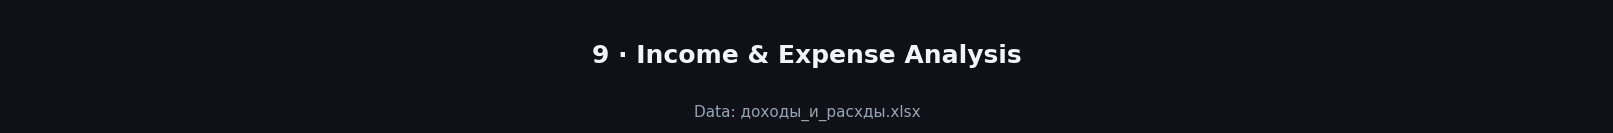

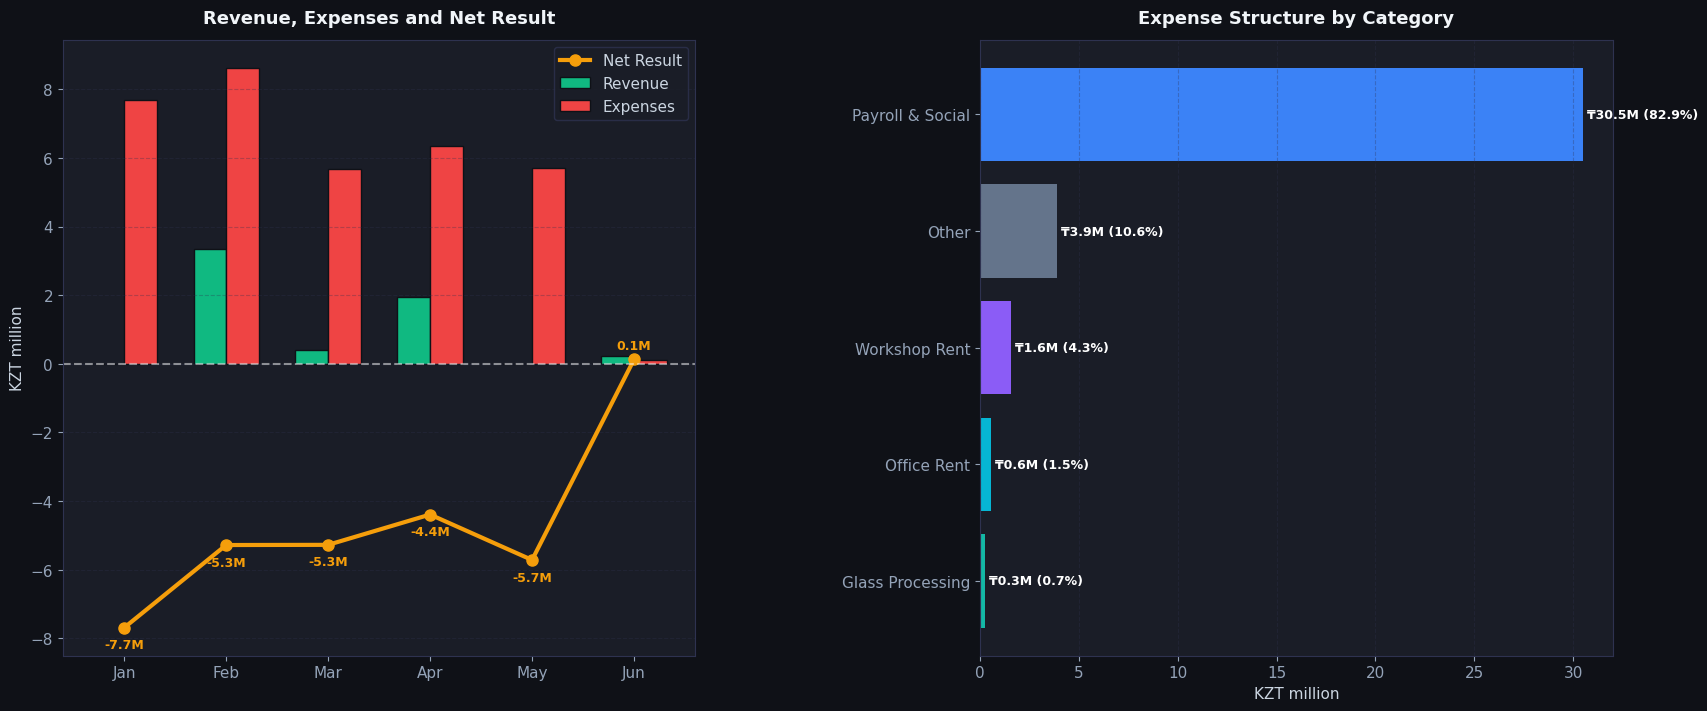

 Income & Expense Key Findings:
• Total Revenue H1 2026: ₸5,930,892
• Total Expenses H1 2026: ₸34,166,039
• Net Financial Result: ₸-28,235,147
• Revenue covered only 17.4% of total expenses.
• Payroll and social contributions are the largest expense category.
• The company operated at a loss during most months of H1 2026.
• June was the only month with a positive financial result.
• Cost optimization and revenue growth are required to improve profitability.


In [84]:
#  Data from доходы_и_расхды.xlsx

revenue = [0, 3346607, 393621, 1951698, 0, 238966]

expenses = [7691957, 8628600, 5670248, 6345193, 5717972, 112069]

pnl = [-7691957, -5281994, -5276628, -4393494, -5717972, 126897]

expense_cats = {
    'Payroll & Social': [
        7068302,
        7744949,
        4993220,
        5495975,
        5177328,
        0
    ],
    'Workshop Rent': [
        0,
        628000,
        314000,
        314000,
        314000,
        0
    ],
    'Office Rent': [
        114000,
        114000,
        114000,
        114000,
        114000,
        0
    ],
    'Glass Processing': [
        0,
        71874,
        167033,
        13976,
        0,
        0
    ],
    'Other': [
        1094546,
        745166,
        626146,
        717159,
        613234,
        112069
    ]
}

months_idx = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

section_banner(
    "9 · Income & Expense Analysis",
    "Data: доходы_и_расхды.xlsx"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8)
)

plt.subplots_adjust(wspace=0.45)

#  Revenue vs Expenses
x = np.arange(6)
w = 0.32

axes[0].bar(
    x - w/2,
    np.array(revenue) / 1e6,
    w,
    label='Revenue',
    color=PALETTE['green'],
    edgecolor='#0F1117'
)

axes[0].bar(
    x + w/2,
    np.array(expenses) / 1e6,
    w,
    label='Expenses',
    color=PALETTE['red'],
    edgecolor='#0F1117'
)

axes[0].plot(
    x,
    np.array(pnl) / 1e6,
    color=PALETTE['amber'],
    marker='o',
    linewidth=3,
    markersize=8,
    label='Net Result'
)

axes[0].axhline(
    0,
    color='white',
    linestyle='--',
    alpha=0.5
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(months_idx)

axes[0].set_ylabel(
    'KZT million',
    color='#CBD5E1'
)

axes[0].set_title(
    'Revenue, Expenses and Net Result',
    fontsize=13,
    color='#F1F5F9',
    fontweight='bold'
)

axes[0].legend()

axes[0].grid(
    axis='y',
    alpha=0.3
)

for i, val in enumerate(pnl):

    offset = -0.6 if val < 0 else 0.3

    axes[0].text(
        i,
        val/1e6 + offset,
        f'{val/1e6:.1f}M',
        ha='center',
        color=PALETTE['amber'],
        fontsize=9,
        fontweight='bold'
    )
#  Expense Structure (Horizontal Bar Chart)

exp_total_by_cat = {
    cat: sum(vals)
    for cat, vals in expense_cats.items()
}

expense_df = pd.DataFrame({
    'Category': list(exp_total_by_cat.keys()),
    'Amount': list(exp_total_by_cat.values())
})

expense_df = expense_df.sort_values(
    'Amount',
    ascending=True
)

colors_exp = [
    PALETTE['teal'],
    PALETTE['cyan'],
    PALETTE['purple'],
    PALETTE['slate'],
    PALETTE['blue']
]

bars = axes[1].barh(
    expense_df['Category'],
    expense_df['Amount'] / 1e6,
    color=colors_exp
)

axes[1].set_title(
    'Expense Structure by Category',
    fontsize=13,
    color='#F1F5F9',
    fontweight='bold'
)

axes[1].set_xlabel(
    'KZT million',
    color='#CBD5E1'
)

axes[1].grid(
    axis='x',
    alpha=0.3
)

total_exp = expense_df['Amount'].sum()

for bar, val in zip(bars, expense_df['Amount']):

    share = val / total_exp * 100

    axes[1].text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'₸{val/1e6:.1f}M ({share:.1f}%)',
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.show()

total_rev = sum(revenue)
total_exp2 = sum(expenses)

print(" Income & Expense Key Findings:")

print(f"• Total Revenue H1 2026: ₸{total_rev:,.0f}")
print(f"• Total Expenses H1 2026: ₸{total_exp2:,.0f}")
print(f"• Net Financial Result: ₸{total_rev-total_exp2:,.0f}")
print(f"• Revenue covered only {total_rev/total_exp2*100:.1f}% of total expenses.")
print("• Payroll and social contributions are the largest expense category.")
print("• The company operated at a loss during most months of H1 2026.")
print("• June was the only month with a positive financial result.")
print("• Cost optimization and revenue growth are required to improve profitability.")



## 10  Accounting Position Analysis (Trial Balance)

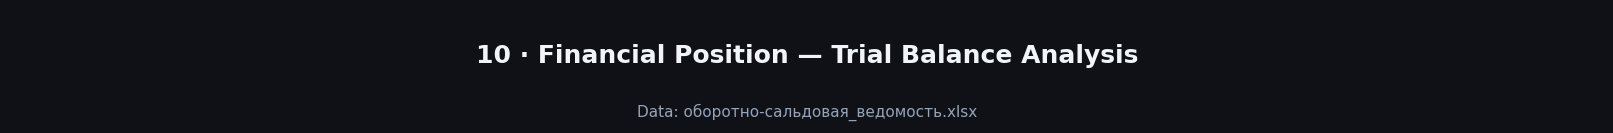

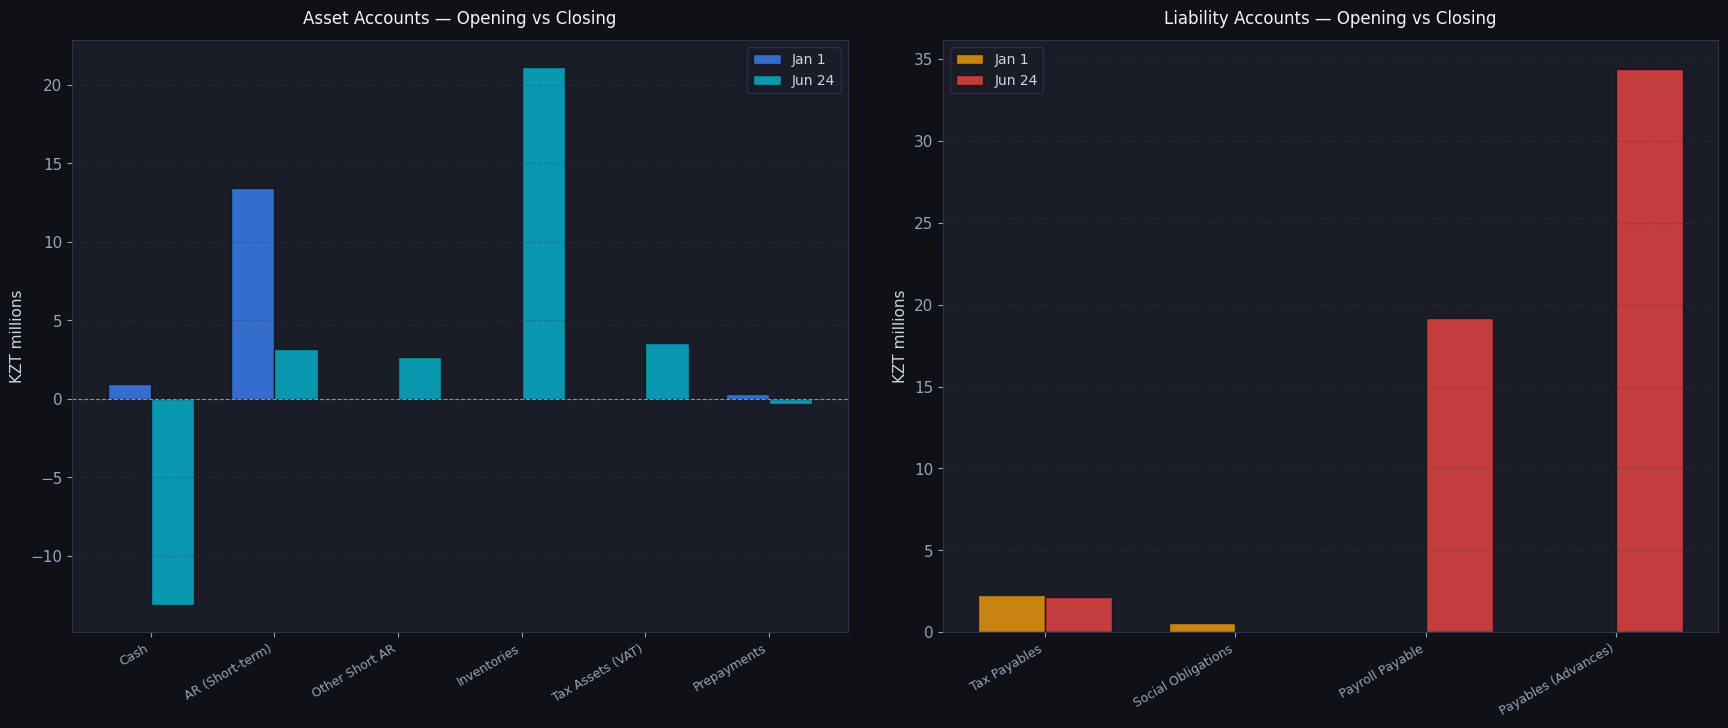

 Trial Balance Key Observations:
   • Payroll payable (3300) surged to ₸19.2M — indicates deferred salary obligations
   • Account 3500 (advances received) at ₸34.4M — significant client prepayments
   • Inventories built from ₸0 to ₸21.1M — new stock acquired in H1
   • Cash turned deeply negative — bank overdraft or negative reconciliation


In [85]:
#  Data from оборотно-сальдовая_ведомость.xlsx
# Key accounts from the Kazakhstani Chart of Accounts (КПС)
accounts_assets = {
    '1000 Cash':                  {'open': 967111.46,  'close': -13130693.14},
    '1200 AR (Short-term)':       {'open': 13425000,   'close': 3197205},
    '1270 Other Short AR':        {'open': 0,          'close': 2656800},
    '1300 Inventories':           {'open': 0,          'close': 21108934.71},
    '1400 Tax Assets (VAT)':      {'open': 0,          'close': 3533375.95},
    '1700 Prepayments':           {'open': 318809,     'close': -325707},
}
accounts_liab = {
    '3100 Tax Payables':          {'open': -2255698.86, 'close': 2147922.4},
    '3200 Social Obligations':    {'open': -529461,     'close': -91088.88},
    '3300 Payroll Payable':       {'open': 0,           'close': -19180602},
    '3500 Payables (Advances)':   {'open': 0,           'close': -34421124},
}

section_banner("10 · Financial Position — Trial Balance Analysis",
               "Data: оборотно-сальдовая_ведомость.xlsx")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Assets waterfall
asset_names = [k.split(' ', 1)[1][:22] for k in accounts_assets]
asset_open  = [v['open'] for v in accounts_assets.values()]
asset_close = [v['close'] for v in accounts_assets.values()]
x_a = np.arange(len(asset_names))
w_a = 0.35

b1 = axes[0].bar(x_a - w_a/2, np.array(asset_open)/1e6,  w_a,
                 label='Jan 1', color=PALETTE['blue'], edgecolor='#0F1117', alpha=0.8)
b2 = axes[0].bar(x_a + w_a/2, np.array(asset_close)/1e6, w_a,
                 label='Jun 24', color=PALETTE['cyan'], edgecolor='#0F1117', alpha=0.8)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_xticks(x_a)
axes[0].set_xticklabels(asset_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('KZT millions', color='#CBD5E1')
axes[0].set_title('Asset Accounts — Opening vs Closing', fontsize=12, color='#F1F5F9')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

#  Liabilities
liab_names = [k.split(' ', 1)[1][:25] for k in accounts_liab]
liab_open  = [abs(v['open']) for v in accounts_liab.values()]
liab_close = [abs(v['close']) for v in accounts_liab.values()]
x_l = np.arange(len(liab_names))

b3 = axes[1].bar(x_l - w_a/2, np.array(liab_open)/1e6,  w_a,
                 label='Jan 1', color=PALETTE['amber'], edgecolor='#0F1117', alpha=0.8)
b4 = axes[1].bar(x_l + w_a/2, np.array(liab_close)/1e6, w_a,
                 label='Jun 24', color=PALETTE['red'], edgecolor='#0F1117', alpha=0.8)
axes[1].set_xticks(x_l)
axes[1].set_xticklabels(liab_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('KZT millions', color='#CBD5E1')
axes[1].set_title('Liability Accounts — Opening vs Closing', fontsize=12, color='#F1F5F9')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig('trial_balance.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()

print(" Trial Balance Key Observations:")
print("   • Payroll payable (3300) surged to ₸19.2M — indicates deferred salary obligations")
print("   • Account 3500 (advances received) at ₸34.4M — significant client prepayments")
print("   • Inventories built from ₸0 to ₸21.1M — new stock acquired in H1")
print("   • Cash turned deeply negative — bank overdraft or negative reconciliation")


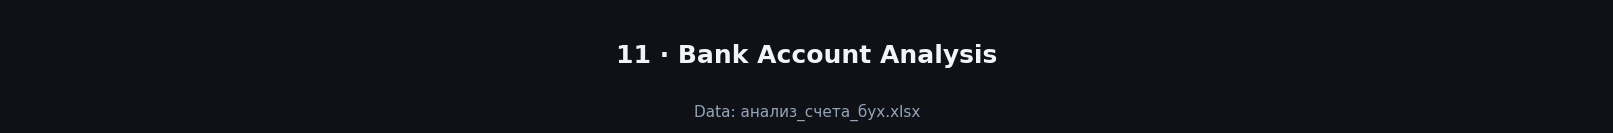

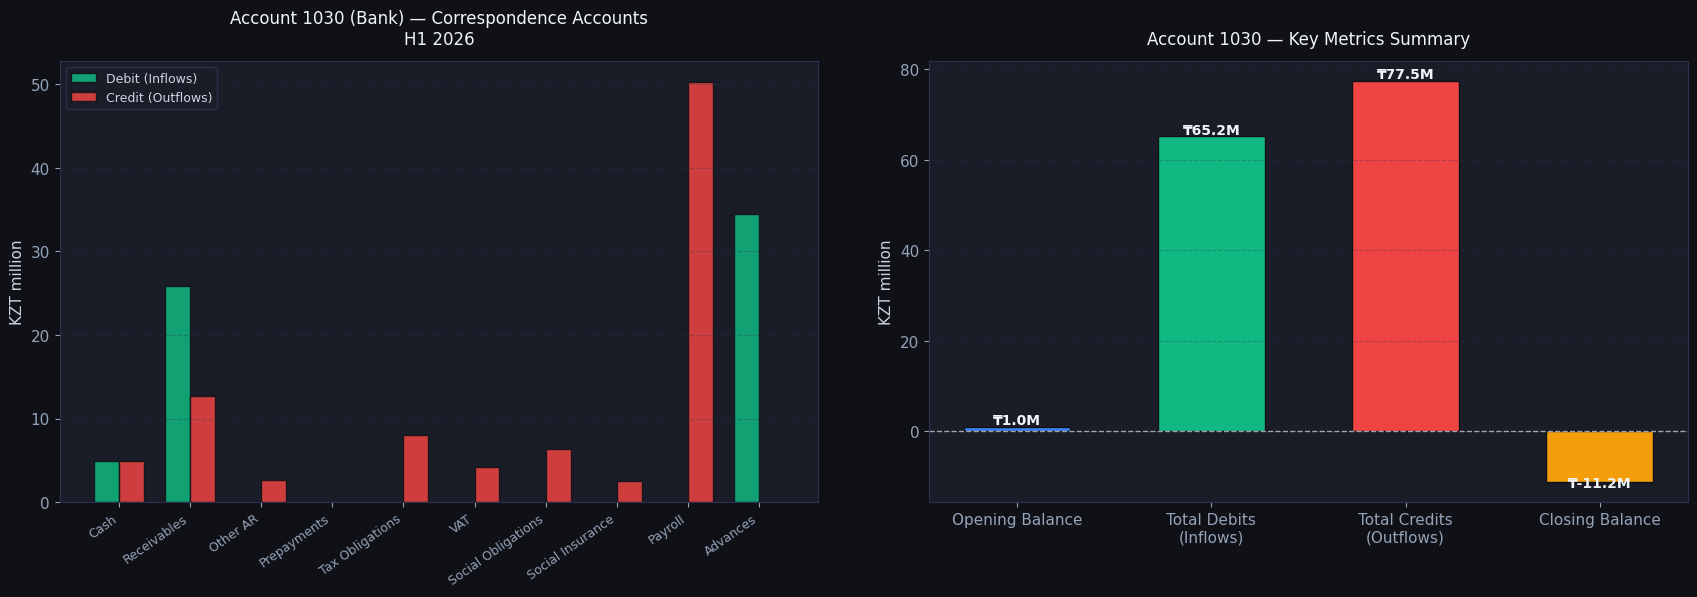

 Bank Account (1030) Key Findings:
• Total cash inflows amounted to ₸65.2M during H1 2026.
• Total cash outflows reached ₸77.5M, exceeding inflows.
• Net cash movement was negative at approximately ₸12.2M.
• Payroll payments (Account 3300) represented the largest cash outflow at ₸50.3M.
• Customer advances (Account 3500) generated significant inflows of ₸34.4M.
• The closing bank balance became negative, indicating liquidity pressure.


In [86]:
#  Account 1030 Detailed Analysis (Bank Account)

bank_corr = {
    'acc': ['1000', '1200', '1270', '1700', '3100', '3130', '3200', '3210', '3300', '3500'],
    'debit': [4961000, 25863279, 0, 0, 0, 0, 0, 0, 0, 34421124],
    'credit': [4961000, 12656800, 2656800, 63303, 8066585, 4235648, 6367353, 2557776, 50296724, 0],
    'labels': [
        'Cash',
        'Receivables',
        'Other AR',
        'Prepayments',
        'Tax Obligations',
        'VAT',
        'Social Obligations',
        'Social Insurance',
        'Payroll',
        'Advances'
    ]
}

section_banner(
    "11 · Bank Account Analysis",
    "Data: анализ_счета_бух.xlsx"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

#  Correspondence Accounts

x = np.arange(len(bank_corr['acc']))
w = 0.35

axes[0].bar(
    x - w/2,
    np.array(bank_corr['debit']) / 1e6,
    w,
    label='Debit (Inflows)',
    color=PALETTE['green'],
    edgecolor='#0F1117',
    alpha=0.85
)

axes[0].bar(
    x + w/2,
    np.array(bank_corr['credit']) / 1e6,
    w,
    label='Credit (Outflows)',
    color=PALETTE['red'],
    edgecolor='#0F1117',
    alpha=0.85
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    bank_corr['labels'],
    rotation=35,
    ha='right',
    fontsize=9
)

axes[0].set_ylabel(
    'KZT million',
    color='#CBD5E1'
)

axes[0].set_title(
    'Account 1030 (Bank) — Correspondence Accounts\nH1 2026',
    fontsize=12,
    color='#F1F5F9'
)

axes[0].legend(fontsize=9)

axes[0].grid(
    axis='y',
    alpha=0.3
)

#  KPI Summary
kpis = {
    'Opening Balance': 967111,
    'Total Debits\n(Inflows)': 65245403,
    'Total Credits\n(Outflows)': 77450765,
    'Closing Balance': -11238250
}

kpi_colors = [
    PALETTE['blue'],
    PALETTE['green'],
    PALETTE['red'],
    PALETTE['amber']
]

bars = axes[1].bar(
    list(kpis.keys()),
    [v / 1e6 for v in kpis.values()],
    color=kpi_colors,
    edgecolor='#0F1117',
    width=0.55
)

axes[1].axhline(
    0,
    color='white',
    linewidth=1,
    linestyle='--',
    alpha=0.6
)

axes[1].set_ylabel(
    'KZT million',
    color='#CBD5E1'
)

axes[1].set_title(
    'Account 1030 — Key Metrics Summary',
    fontsize=12,
    color='#F1F5F9'
)

axes[1].grid(
    axis='y',
    alpha=0.3
)

for bar, val in zip(bars, kpis.values()):

    offset = 0.5 if val > 0 else -1.2

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f'₸{val/1e6:.1f}M',
        ha='center',
        color='#F1F5F9',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout(pad=4)

plt.savefig(
    'bank_account_analysis.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0F1117',
    edgecolor='none'
)

plt.show()

print(" Bank Account (1030) Key Findings:")

print("• Total cash inflows amounted to ₸65.2M during H1 2026.")
print("• Total cash outflows reached ₸77.5M, exceeding inflows.")
print("• Net cash movement was negative at approximately ₸12.2M.")
print("• Payroll payments (Account 3300) represented the largest cash outflow at ₸50.3M.")
print("• Customer advances (Account 3500) generated significant inflows of ₸34.4M.")
print("• The closing bank balance became negative, indicating liquidity pressure.")

The chart shows cash inflows and outflows through the company's bank account (Account 1030). Customer advances generated the largest inflow, while payroll payments represented the largest outflow. During H1 2026 total outflows exceeded inflows, resulting in a negative closing balance and liquidity pressure.


## 11  Final Business Conclusions & Recommendations

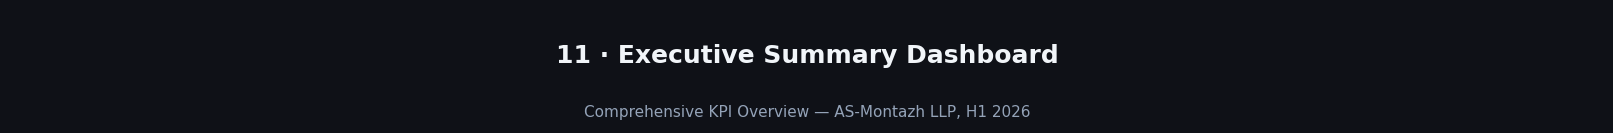

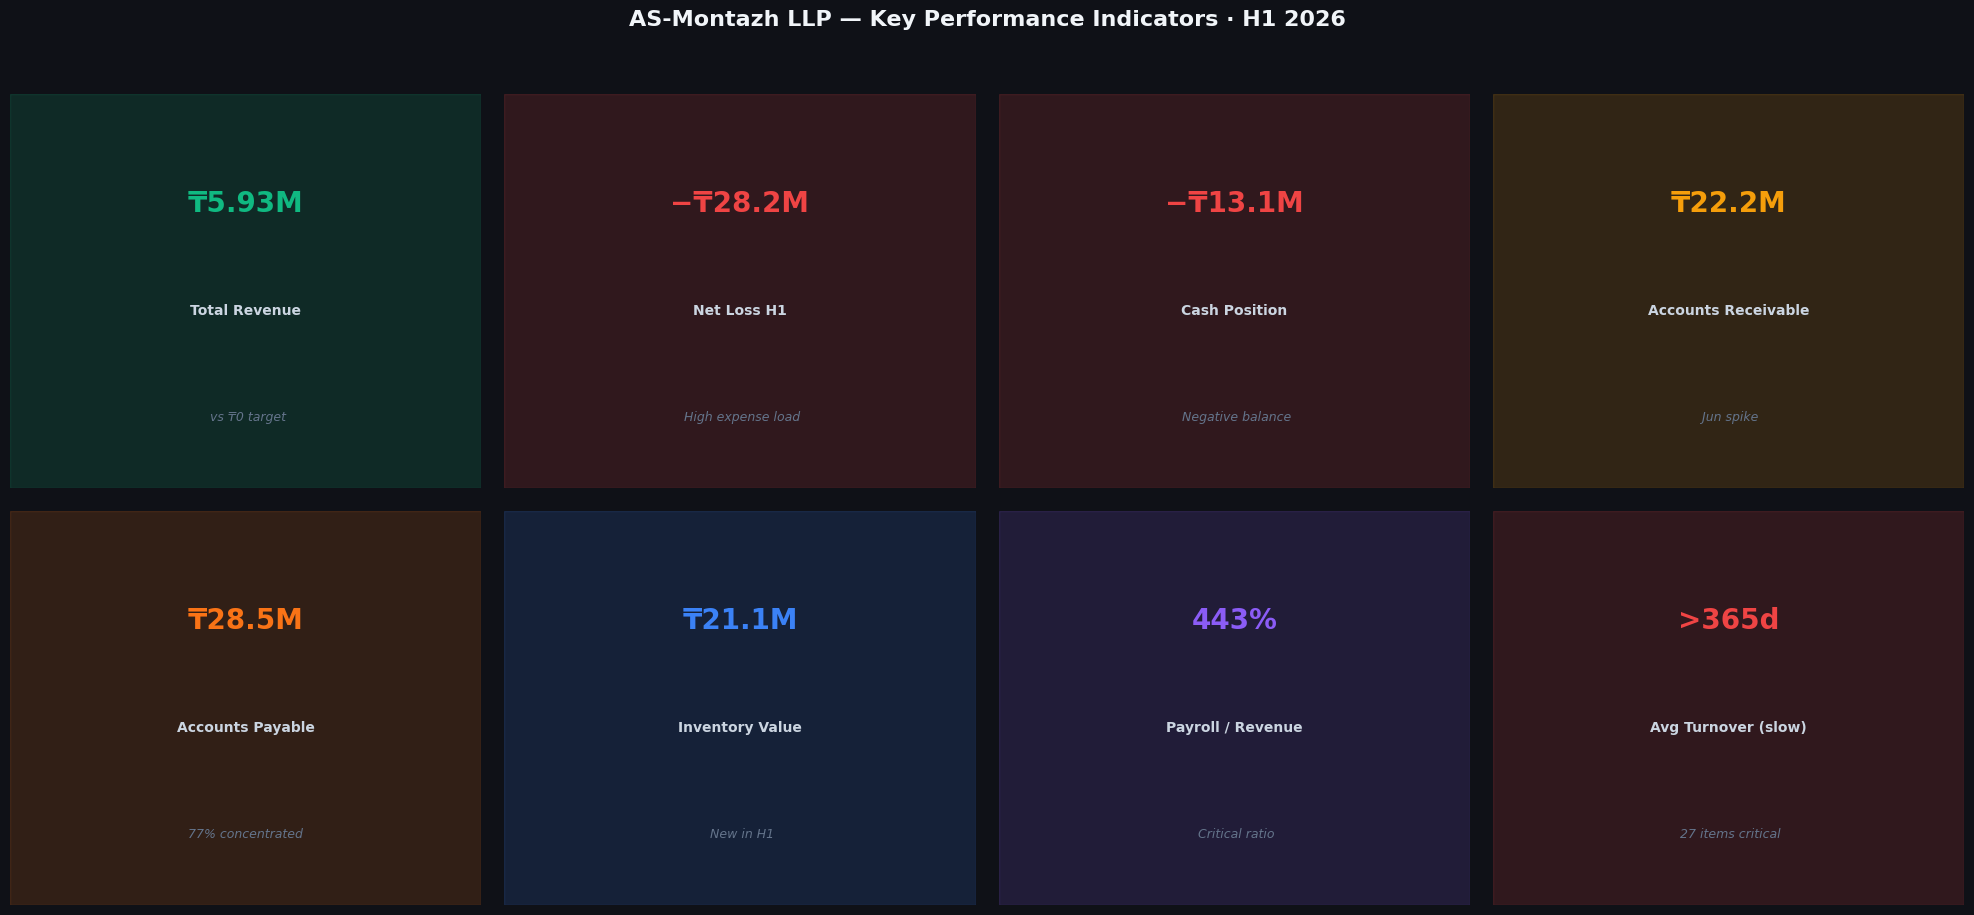

In [87]:
#  Summary KPI Dashboard
section_banner("11 · Executive Summary Dashboard",
               "Comprehensive KPI Overview — AS-Montazh LLP, H1 2026")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

kpi_data = [
    ('Total Revenue', '₸5.93M', PALETTE['green'],  ' vs ₸0 target'),
    ('Net Loss H1', '−₸28.2M', PALETTE['red'],     ' High expense load'),
    ('Cash Position', '−₸13.1M', PALETTE['red'],   ' Negative balance'),
    ('Accounts Receivable', '₸22.2M', PALETTE['amber'], ' Jun spike'),
    ('Accounts Payable', '₸28.5M', PALETTE['orange'], '77% concentrated'),
    ('Inventory Value', '₸21.1M', PALETTE['blue'],  ' New in H1'),
    ('Payroll / Revenue', '443%', PALETTE['purple'], ' Critical ratio'),
    ('Avg Turnover (slow)', '>365d', PALETTE['red'], ' 27 items critical'),
]

for i, (ax, (title, value, color, sub)) in enumerate(zip(axes, kpi_data)):
    ax.set_facecolor(color + '22')
    ax.add_patch(plt.Rectangle((0,0), 1, 1, transform=ax.transAxes,
                                color=color, alpha=0.15))
    ax.text(0.5, 0.72, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=20, fontweight='bold', color=color)
    ax.text(0.5, 0.45, title, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#CBD5E1', fontweight='bold')
    ax.text(0.5, 0.18, sub, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#64748B', style='italic')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

plt.suptitle('AS-Montazh LLP — Key Performance Indicators · H1 2026',
             fontsize=16, color='#F1F5F9', fontweight='bold', y=1.02)
plt.tight_layout(pad=1.5)
plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117', edgecolor='none')
plt.show()


## Executive Conclusions

### 1. Financial Performance

The company generated total revenue of ₸5.9M during H1 2026, while total expenses reached ₸34.2M. As a result, AS-Montazh recorded a net loss of approximately ₸28.2M. Revenue covered only 17.4% of operating expenses.

### 2. Cost Structure

Payroll and social contributions represented the largest expense category, accounting for more than 80% of total costs. This indicates a significant imbalance between labor costs and revenue generation.

### 3. Inventory Management

Inventory increased to ₸21.1M during the reporting period. Several products demonstrated extremely low turnover, indicating excess stock and capital tied up in inventory.

### 4. Receivables and Payables

Accounts receivable increased to ₸22.2M by June 2026, while accounts payable reached ₸28.5M. A large share of payables is concentrated with one supplier, creating supplier dependency risk.

### 5. Liquidity Position

Cash outflows exceeded inflows during H1 2026, resulting in a negative closing bank balance. This indicates liquidity pressure and the need for improved cash flow management.

## Recommendations

* Increase sales activity and revenue generation.
* Optimize payroll and operating expenses.
* Reduce slow-moving inventory.
* Improve collection of receivables.
* Diversify the supplier base.
* Implement monthly cash flow monitoring and forecasting.

## Methodology

The analysis was performed using accounting data extracted from 1C:Enterprise 8.3. Standard financial analysis methods were applied, including turnover analysis, accounts receivable and payable analysis, cash flow analysis, and financial position assessment.
